In [51]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



#### import dataset


In [3]:
df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.shape

(1460, 81)

In [5]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
df1=df.isnull().sum()/df.shape[0]*100 
df1[df1>0].sort_values(ascending=False)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

#### Data Cleaning


In [8]:

cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'LotFrontage', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',  'MasVnrArea']
for col in cols:
    df[col] = df[col].fillna("None")


<Figure size 1500x1000 with 0 Axes>

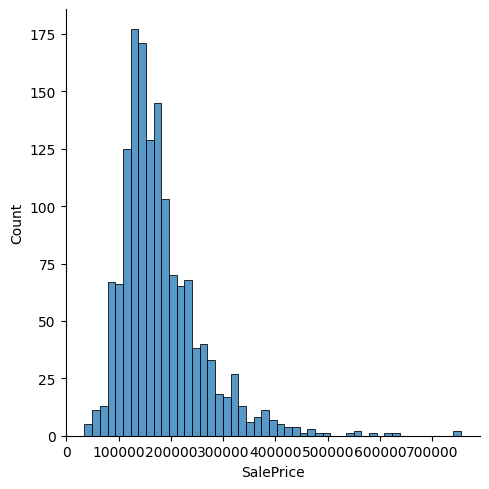

In [9]:
plt.figure(figsize=(15,10))
sns.displot(df['SalePrice'])
plt.show()

####  From the above graph we can clearly see that target variable SalePrice is right skewed 

In [10]:
print("Skewness: ", df['SalePrice'].skew())
print("Kurtosis: ", df['SalePrice'].kurt())

Skewness:  1.8828757597682129
Kurtosis:  6.536281860064529


#### we can observe that target variable has skewness greater than 1 and has hog density around saleprice of 16000

#### so we can do transformation for this variable

In [11]:
# log transformation
df['SalePrice']= np.log(df['SalePrice'])

<Figure size 1000x600 with 0 Axes>

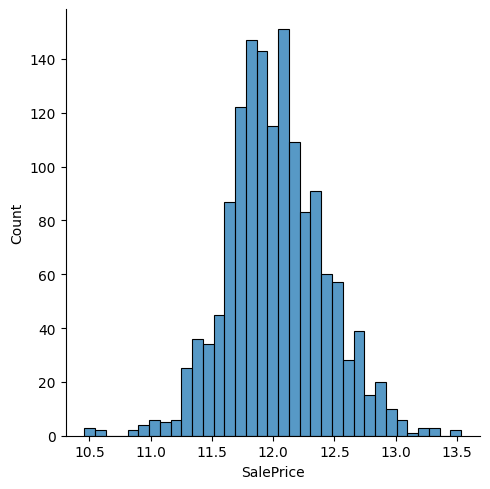

In [12]:
# checking the distribution after log transformation
plt.figure(figsize=(10,6))
sns.displot(df['SalePrice'])
plt.show()

- Drop ID column
- convert few columns into object datatype
- convert few columns into numeric data type

In [13]:
df.drop(['Id'], axis=1, inplace=True)

In [14]:
df[['MSSubClass','OverallQual','OverallCond']] = df[['MSSubClass','OverallQual','OverallCond']].astype('object')

In [15]:
df['LotFrontage'] = pd.to_numeric(df['LotFrontage'], errors='coerce')
df['MasVnrArea'] = pd.to_numeric(df['MasVnrArea'], errors='coerce')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   object 
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   object 
 17  OverallCond    1460 non-null   object 
 18  YearBuil

In [17]:
null_cols= df.columns[df.isnull().any()]
null_cols

Index(['LotFrontage', 'MasVnrType', 'MasVnrArea', 'Electrical'], dtype='object')

In [18]:
for i in null_cols:
    if df[i].dtype == np.float64 or df[i].dtype == np.int64:
        df[i].fillna(df[i].mean(),inplace=True)
    else:
        df[i].fillna(df[i].mode()[0], inplace=True)

C:\Users\rajve\AppData\Local\Temp\ipykernel_13456\1802400246.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].mean(),inplace=True)
C:\Users\rajve\AppData\Local\Temp\ipykernel_13456\1802400246.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, whe

In [19]:
df.isna().sum()

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 80, dtype: int64

### Exploratory Data Analysis on the Dataset

##### Categorical columns

In [20]:
cat_cols = df.select_dtypes(include = 'object').columns
cat_cols

Index(['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour',
       'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1',
       'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu',
       'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType',
       'SaleCondition'],
      dtype='object')

##### Numerical columns


In [21]:
num_cols= df.select_dtypes(include=['int64','float64']).columns
num_cols

Index(['LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea',
       'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
       '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

#### Univarient Analysis

LotFrontage


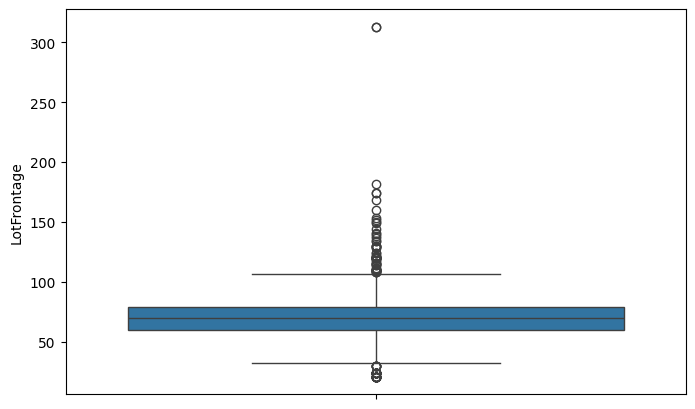

LotArea


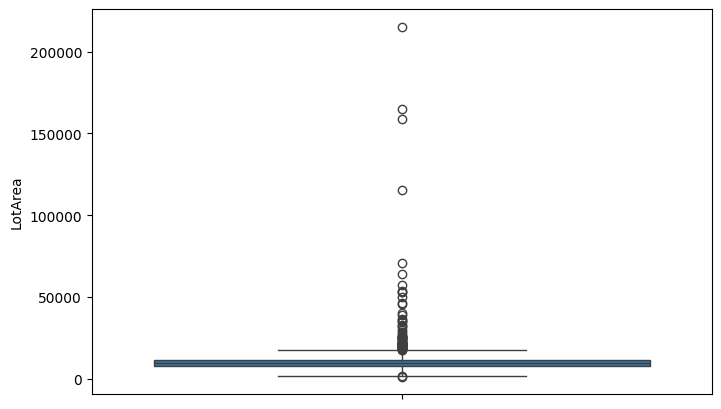

YearBuilt


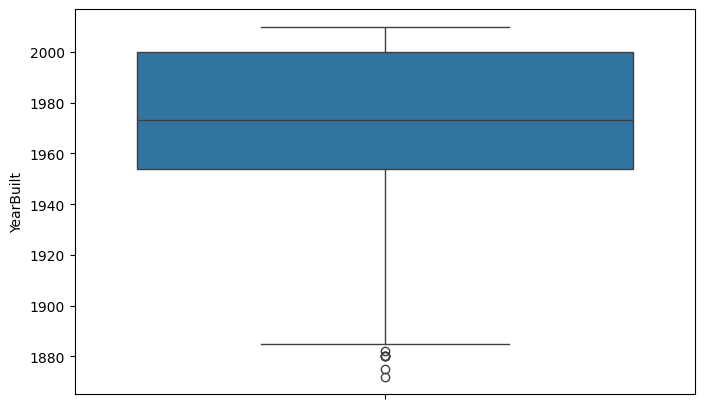

YearRemodAdd


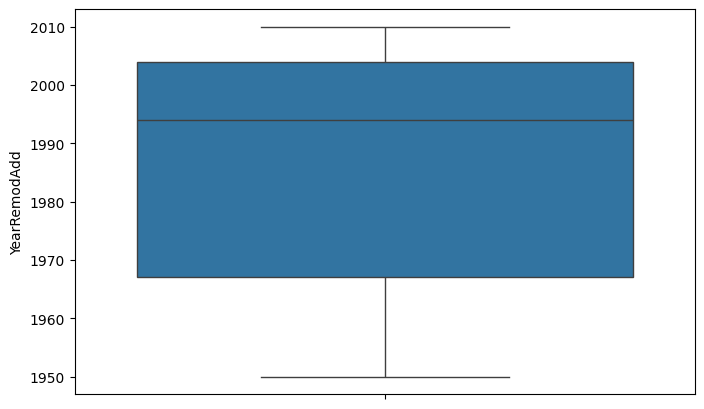

MasVnrArea


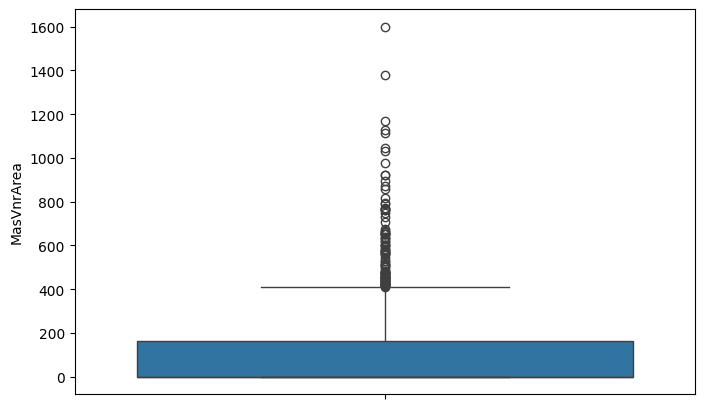

BsmtFinSF1


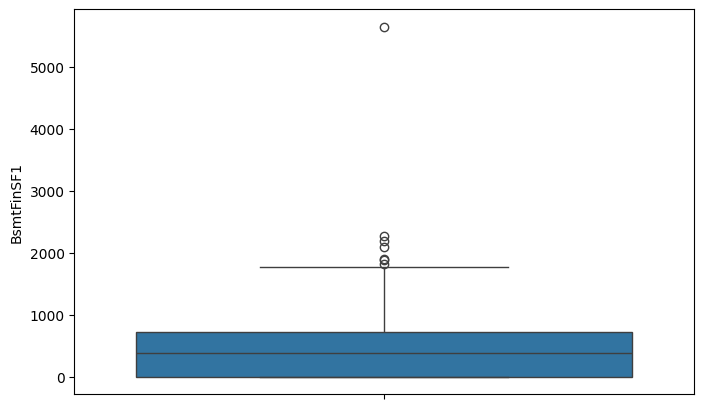

BsmtFinSF2


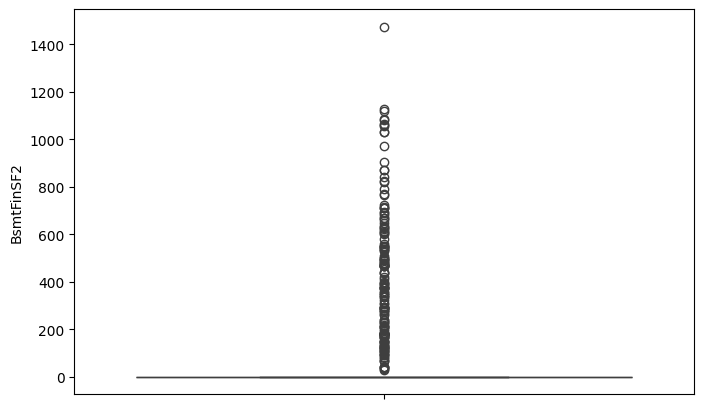

BsmtUnfSF


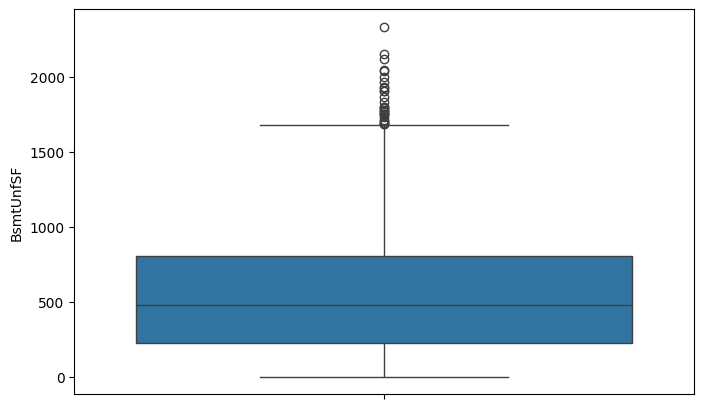

TotalBsmtSF


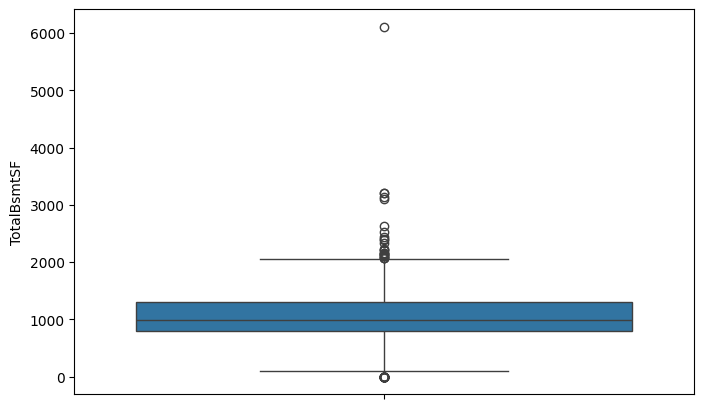

1stFlrSF


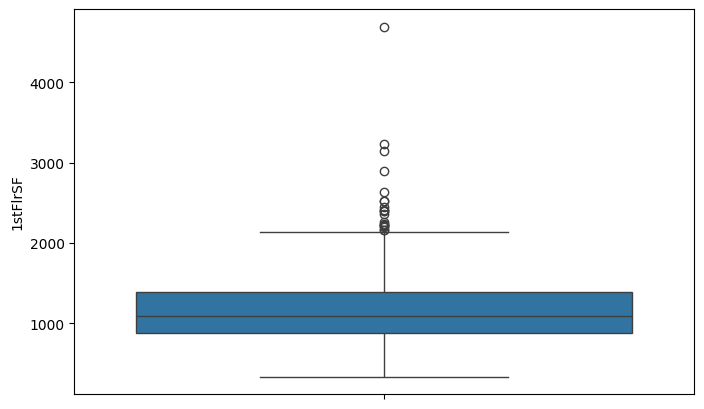

2ndFlrSF


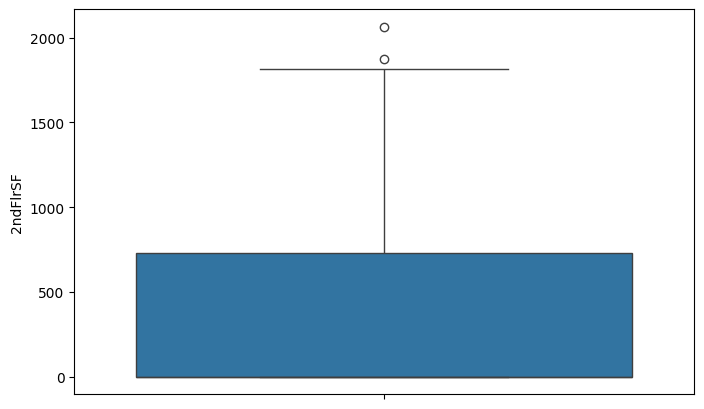

LowQualFinSF


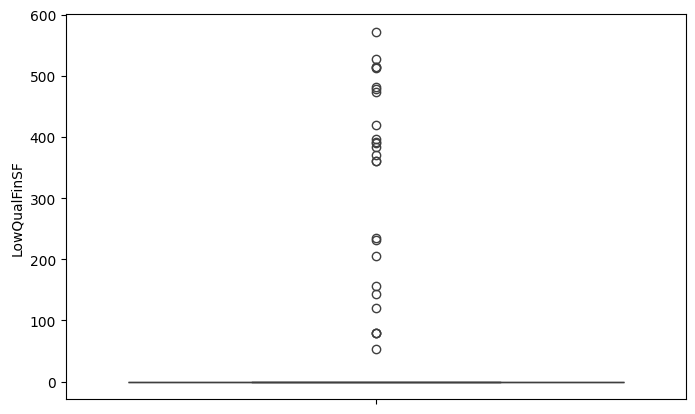

GrLivArea


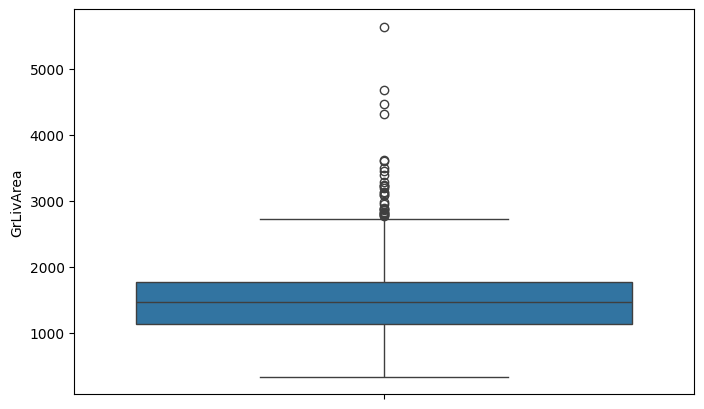

BsmtFullBath


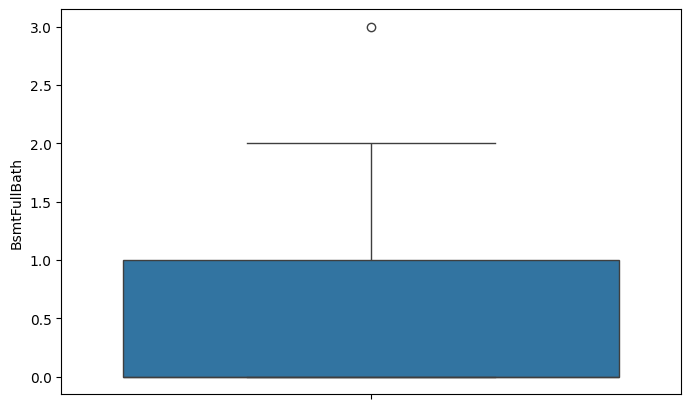

BsmtHalfBath


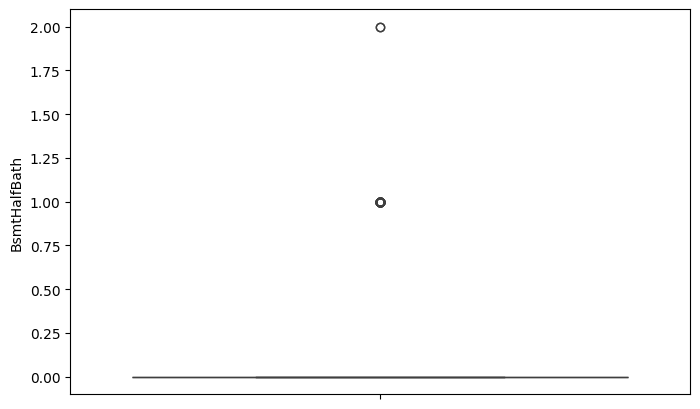

FullBath


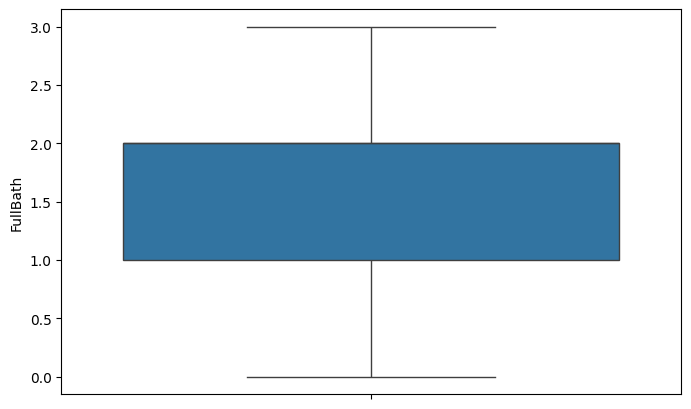

HalfBath


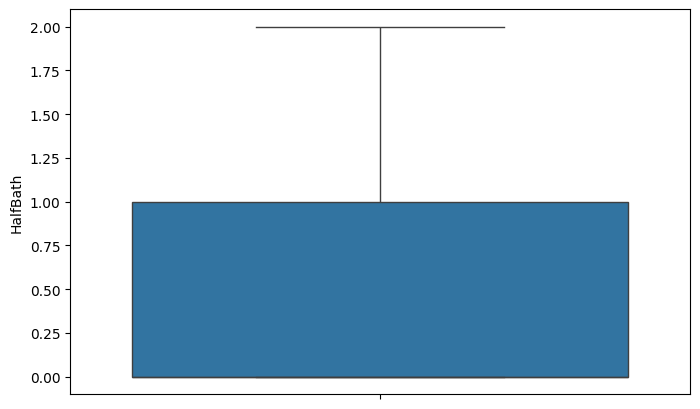

BedroomAbvGr


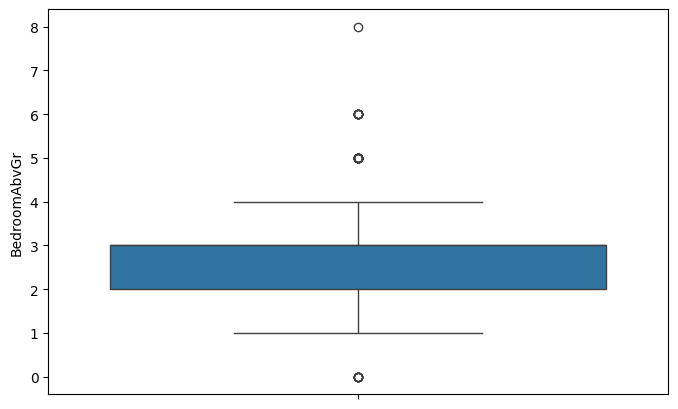

KitchenAbvGr


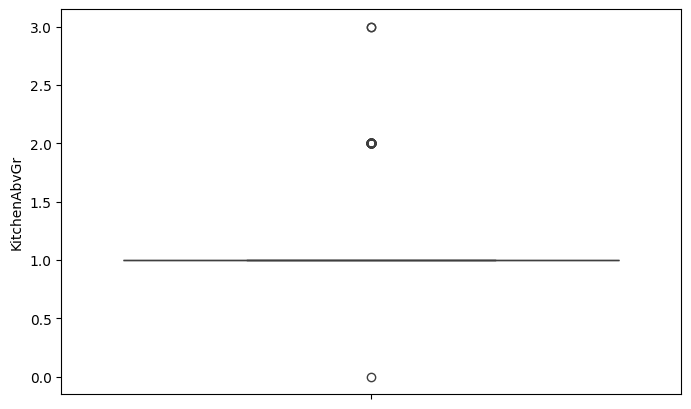

TotRmsAbvGrd


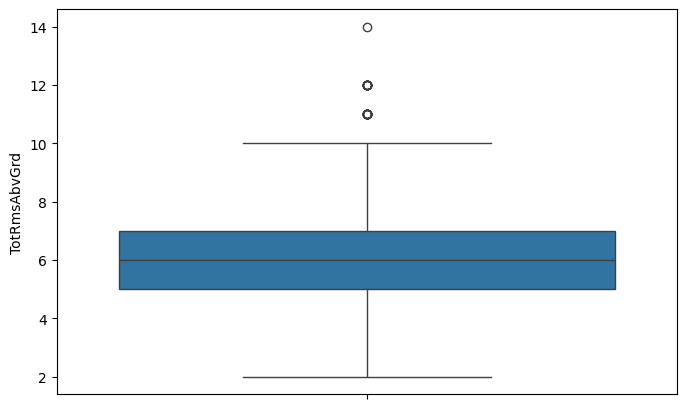

Fireplaces


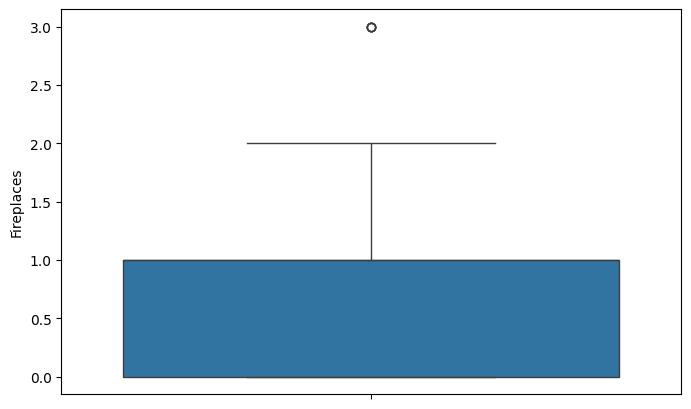

GarageCars


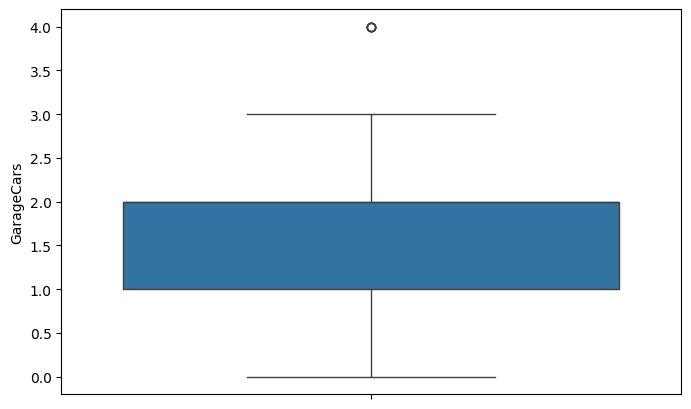

GarageArea


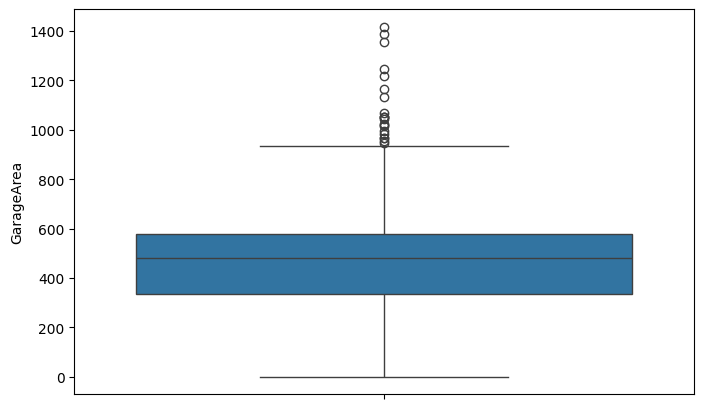

WoodDeckSF


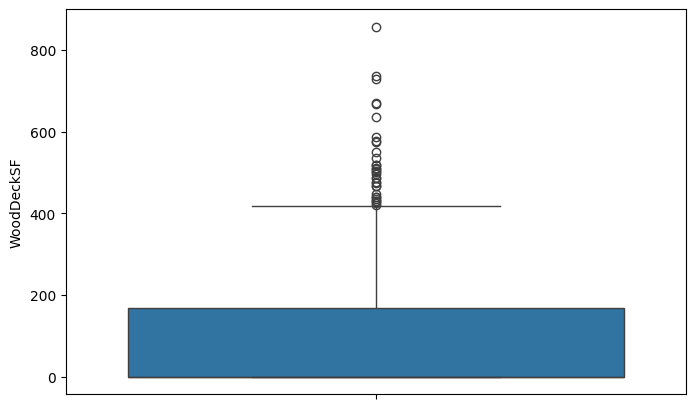

OpenPorchSF


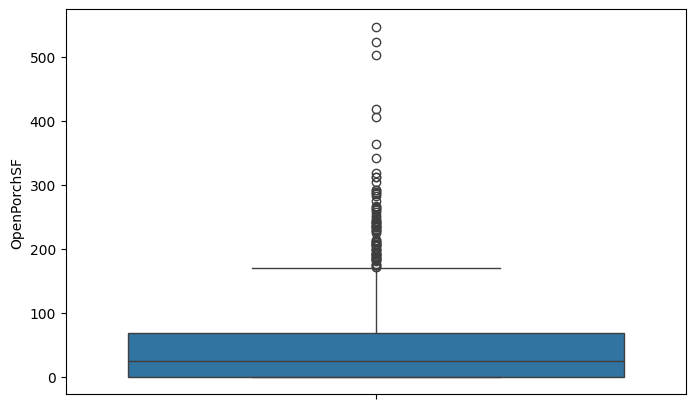

EnclosedPorch


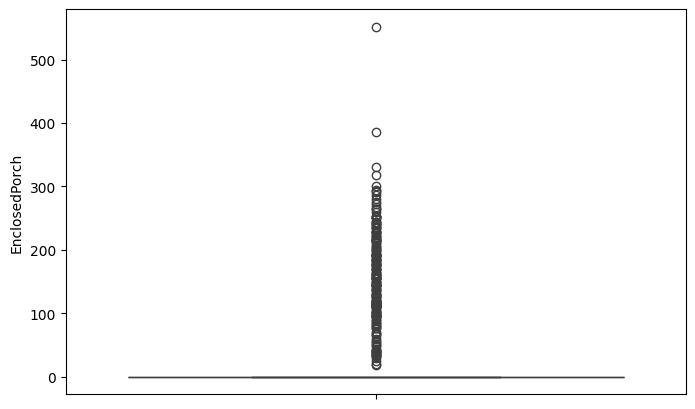

3SsnPorch


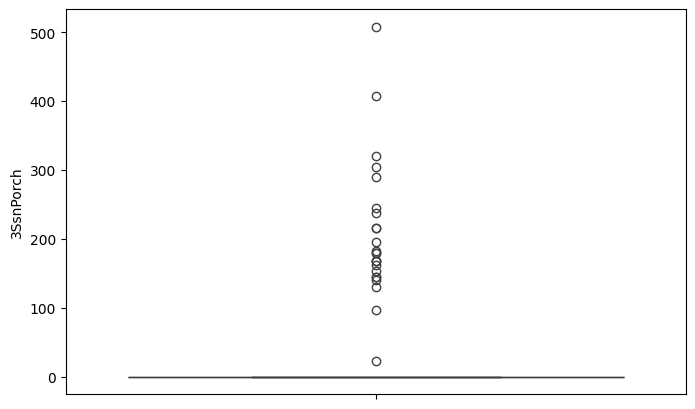

ScreenPorch


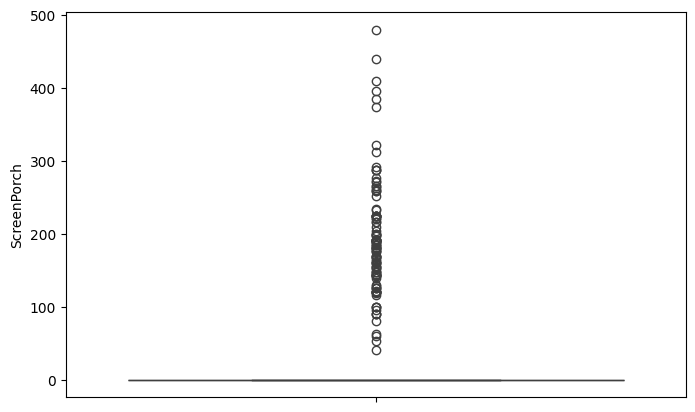

PoolArea


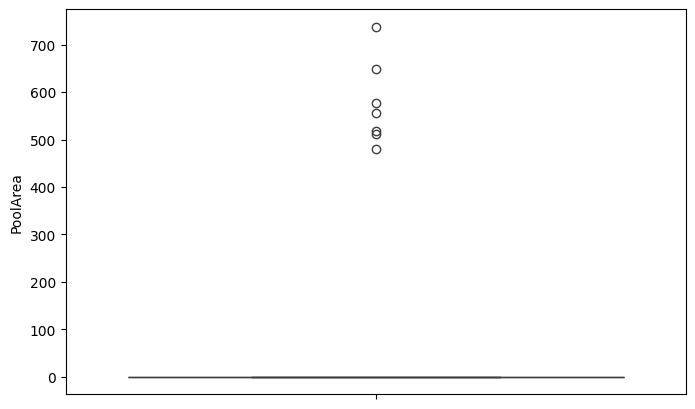

MiscVal


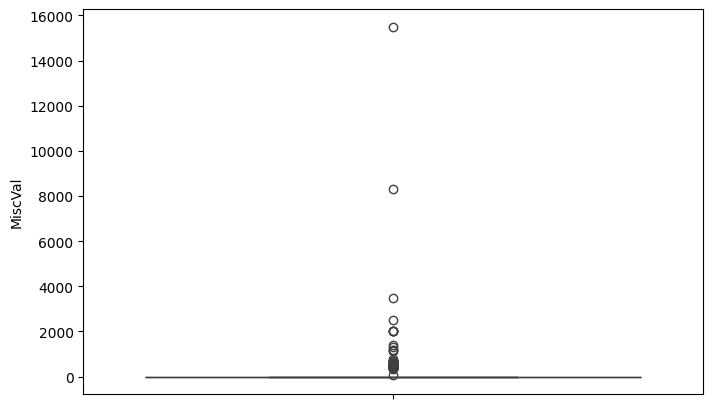

MoSold


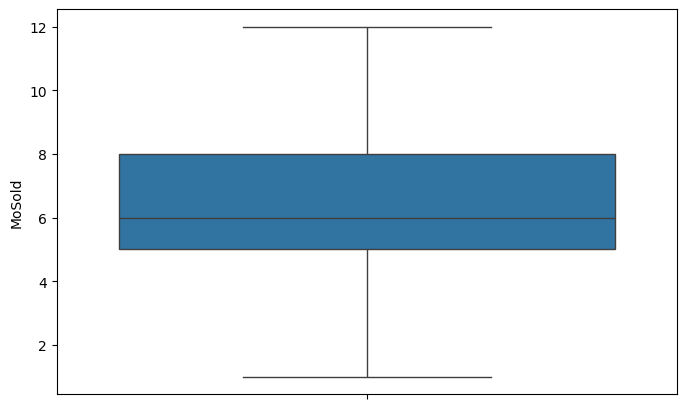

YrSold


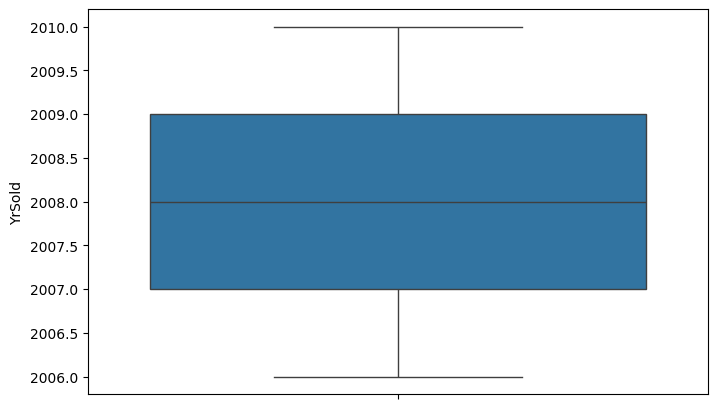

SalePrice


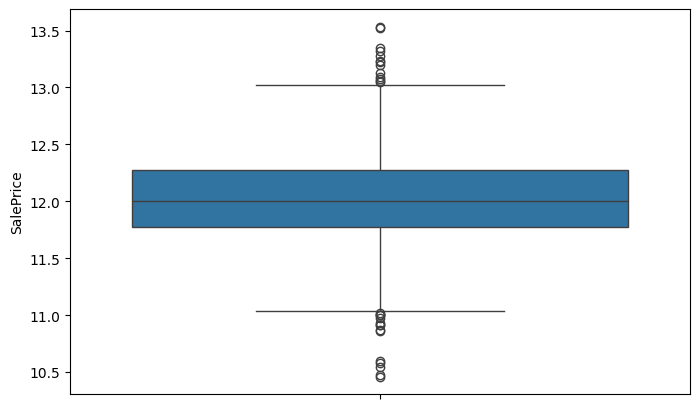

In [22]:
# numerical columns
# plotting boxplots to visualize the distribution and check for outliers

for i in num_cols:
    plt.figure(figsize=(8,5))
    print(i)
    sns.boxplot(df[i])
    plt.show()
    

MSSubClass
20     0.367123
60     0.204795
50     0.098630
120    0.059589
30     0.047260
160    0.043151
70     0.041096
80     0.039726
90     0.035616
190    0.020548
85     0.013699
75     0.010959
45     0.008219
180    0.006849
40     0.002740
Name: proportion, dtype: float64


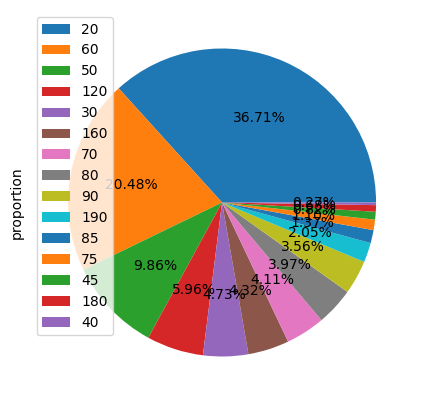

MSZoning
RL         0.788356
RM         0.149315
FV         0.044521
RH         0.010959
C (all)    0.006849
Name: proportion, dtype: float64


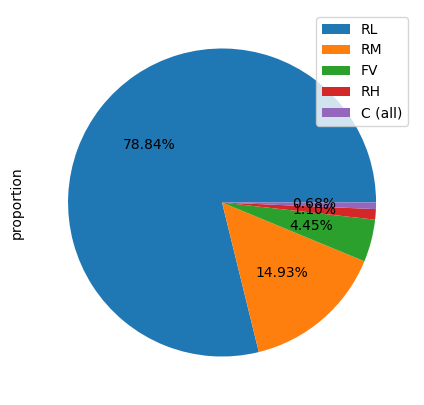

Street
Pave    0.99589
Grvl    0.00411
Name: proportion, dtype: float64


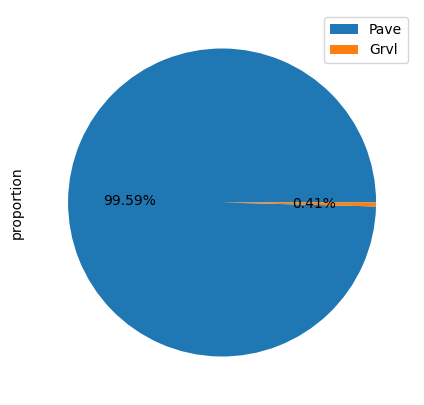

Alley
None    0.937671
Grvl    0.034247
Pave    0.028082
Name: proportion, dtype: float64


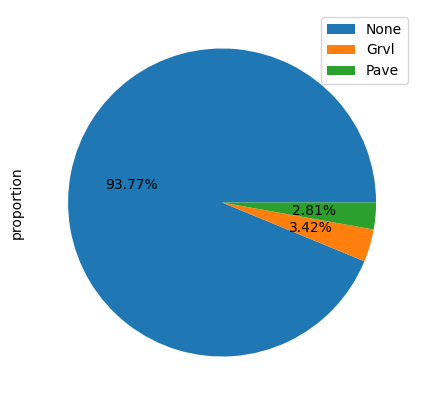

LotShape
Reg    0.633562
IR1    0.331507
IR2    0.028082
IR3    0.006849
Name: proportion, dtype: float64


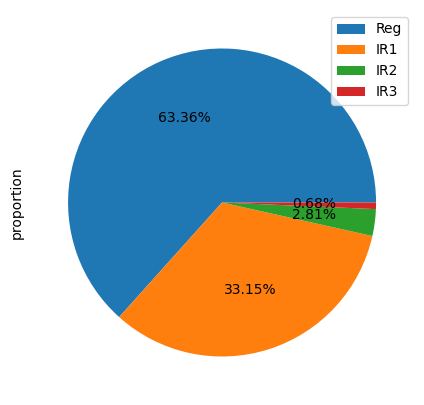

LandContour
Lvl    0.897945
Bnk    0.043151
HLS    0.034247
Low    0.024658
Name: proportion, dtype: float64


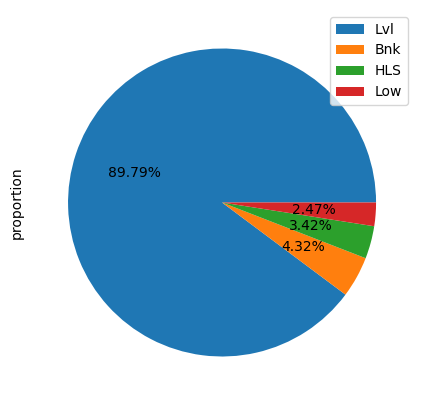

Utilities
AllPub    0.999315
NoSeWa    0.000685
Name: proportion, dtype: float64


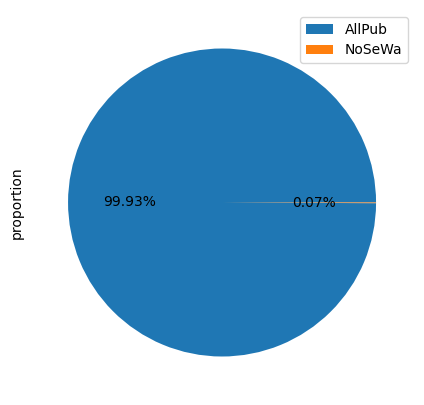

LotConfig
Inside     0.720548
Corner     0.180137
CulDSac    0.064384
FR2        0.032192
FR3        0.002740
Name: proportion, dtype: float64


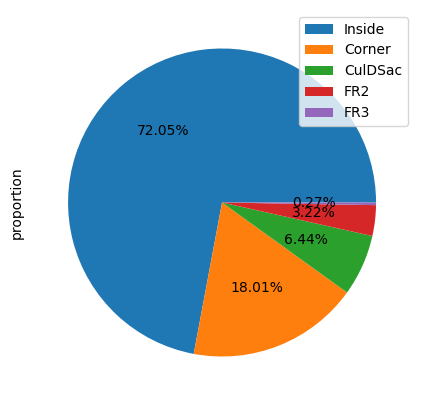

LandSlope
Gtl    0.946575
Mod    0.044521
Sev    0.008904
Name: proportion, dtype: float64


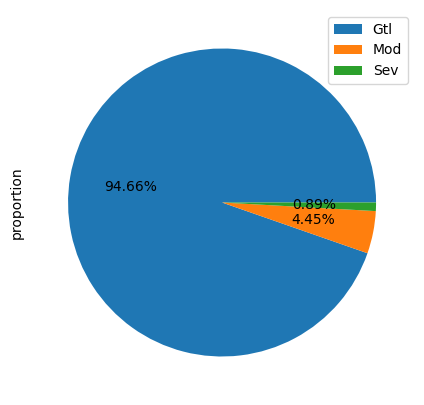

Neighborhood
NAmes      0.154110
CollgCr    0.102740
OldTown    0.077397
Edwards    0.068493
Somerst    0.058904
Gilbert    0.054110
NridgHt    0.052740
Sawyer     0.050685
NWAmes     0.050000
SawyerW    0.040411
BrkSide    0.039726
Crawfor    0.034932
Mitchel    0.033562
NoRidge    0.028082
Timber     0.026027
IDOTRR     0.025342
ClearCr    0.019178
SWISU      0.017123
StoneBr    0.017123
Blmngtn    0.011644
MeadowV    0.011644
BrDale     0.010959
Veenker    0.007534
NPkVill    0.006164
Blueste    0.001370
Name: proportion, dtype: float64


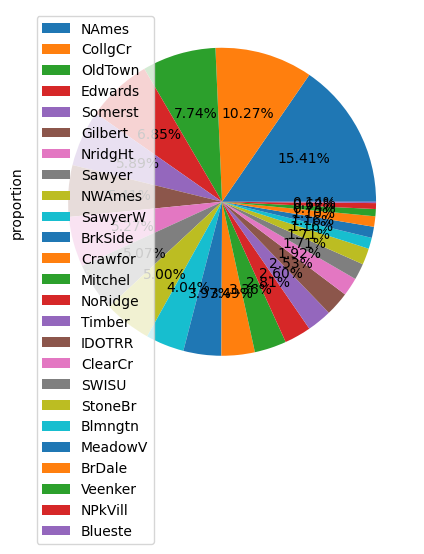

Condition1
Norm      0.863014
Feedr     0.055479
Artery    0.032877
RRAn      0.017808
PosN      0.013014
RRAe      0.007534
PosA      0.005479
RRNn      0.003425
RRNe      0.001370
Name: proportion, dtype: float64


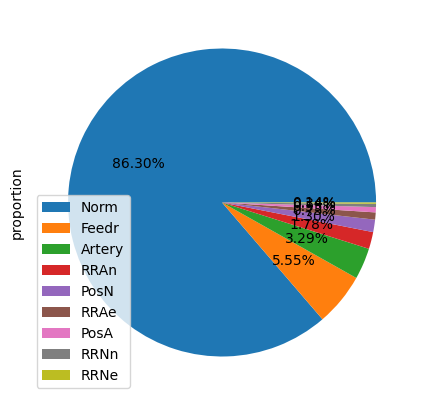

Condition2
Norm      0.989726
Feedr     0.004110
Artery    0.001370
RRNn      0.001370
PosN      0.001370
PosA      0.000685
RRAn      0.000685
RRAe      0.000685
Name: proportion, dtype: float64


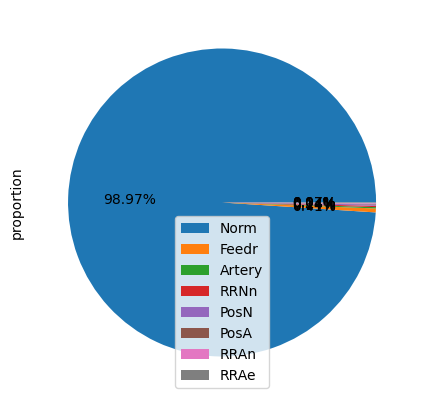

BldgType
1Fam      0.835616
TwnhsE    0.078082
Duplex    0.035616
Twnhs     0.029452
2fmCon    0.021233
Name: proportion, dtype: float64


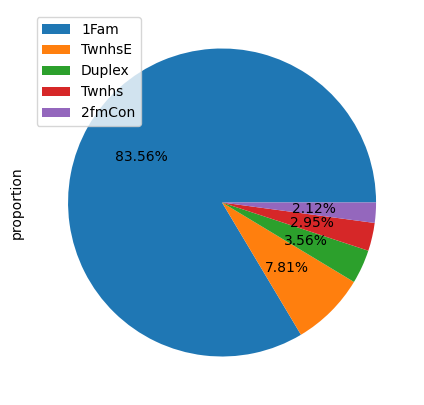

HouseStyle
1Story    0.497260
2Story    0.304795
1.5Fin    0.105479
SLvl      0.044521
SFoyer    0.025342
1.5Unf    0.009589
2.5Unf    0.007534
2.5Fin    0.005479
Name: proportion, dtype: float64


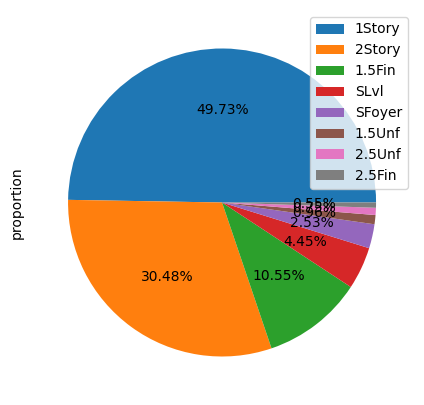

OverallQual
5     0.271918
6     0.256164
7     0.218493
8     0.115068
4     0.079452
9     0.029452
3     0.013699
10    0.012329
2     0.002055
1     0.001370
Name: proportion, dtype: float64


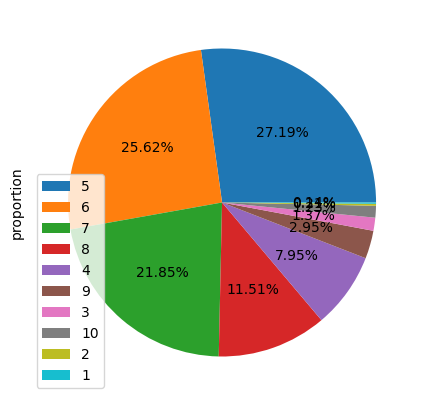

OverallCond
5    0.562329
6    0.172603
7    0.140411
8    0.049315
4    0.039041
3    0.017123
9    0.015068
2    0.003425
1    0.000685
Name: proportion, dtype: float64


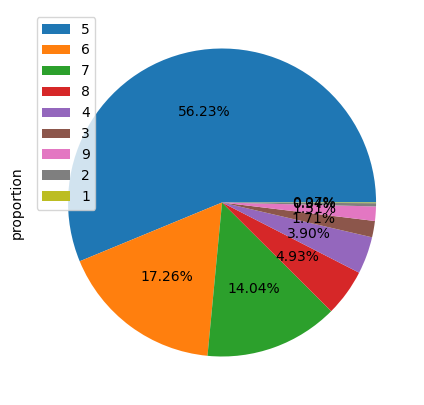

RoofStyle
Gable      0.781507
Hip        0.195890
Flat       0.008904
Gambrel    0.007534
Mansard    0.004795
Shed       0.001370
Name: proportion, dtype: float64


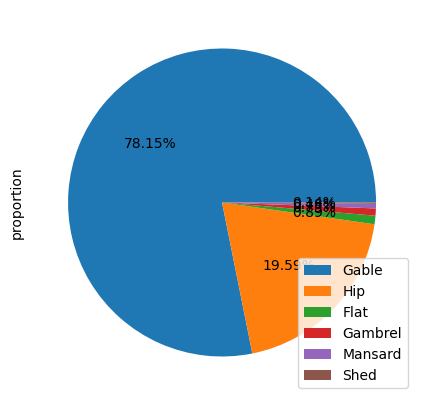

RoofMatl
CompShg    0.982192
Tar&Grv    0.007534
WdShngl    0.004110
WdShake    0.003425
Metal      0.000685
Membran    0.000685
Roll       0.000685
ClyTile    0.000685
Name: proportion, dtype: float64


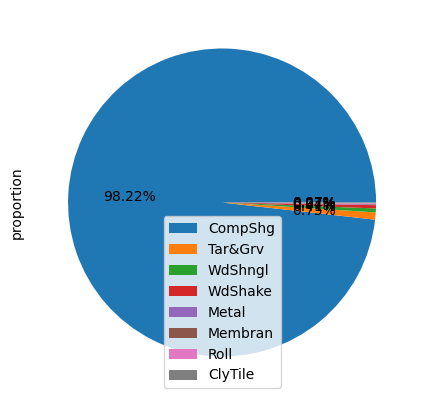

Exterior1st
VinylSd    0.352740
HdBoard    0.152055
MetalSd    0.150685
Wd Sdng    0.141096
Plywood    0.073973
CemntBd    0.041781
BrkFace    0.034247
WdShing    0.017808
Stucco     0.017123
AsbShng    0.013699
BrkComm    0.001370
Stone      0.001370
AsphShn    0.000685
ImStucc    0.000685
CBlock     0.000685
Name: proportion, dtype: float64


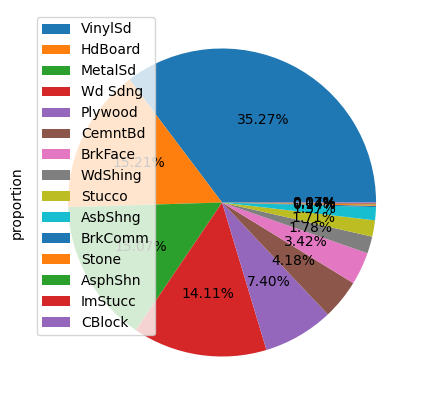

Exterior2nd
VinylSd    0.345205
MetalSd    0.146575
HdBoard    0.141781
Wd Sdng    0.134932
Plywood    0.097260
CmentBd    0.041096
Wd Shng    0.026027
Stucco     0.017808
BrkFace    0.017123
AsbShng    0.013699
ImStucc    0.006849
Brk Cmn    0.004795
Stone      0.003425
AsphShn    0.002055
Other      0.000685
CBlock     0.000685
Name: proportion, dtype: float64


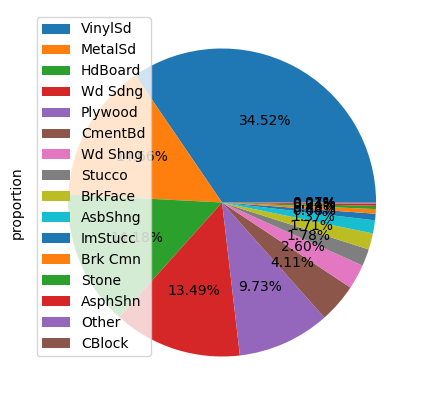

MasVnrType
BrkFace    0.902055
Stone      0.087671
BrkCmn     0.010274
Name: proportion, dtype: float64


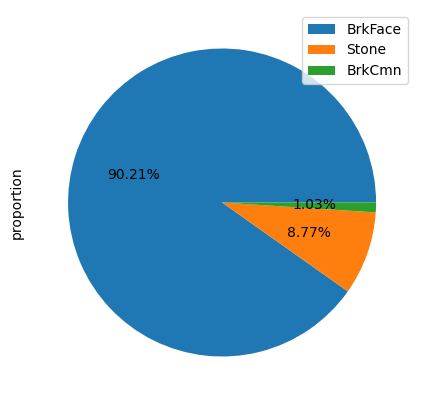

ExterQual
TA    0.620548
Gd    0.334247
Ex    0.035616
Fa    0.009589
Name: proportion, dtype: float64


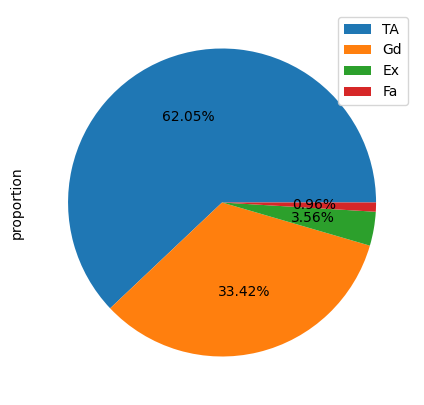

ExterCond
TA    0.878082
Gd    0.100000
Fa    0.019178
Ex    0.002055
Po    0.000685
Name: proportion, dtype: float64


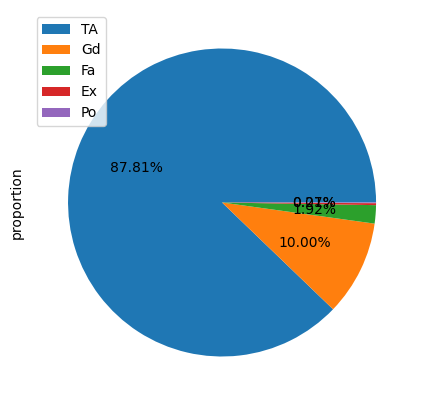

Foundation
PConc     0.443151
CBlock    0.434247
BrkTil    0.100000
Slab      0.016438
Stone     0.004110
Wood      0.002055
Name: proportion, dtype: float64


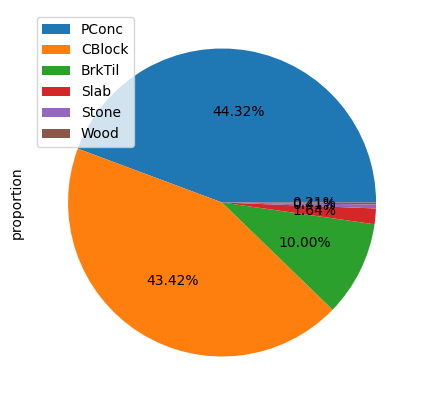

BsmtQual
TA      0.444521
Gd      0.423288
Ex      0.082877
None    0.025342
Fa      0.023973
Name: proportion, dtype: float64


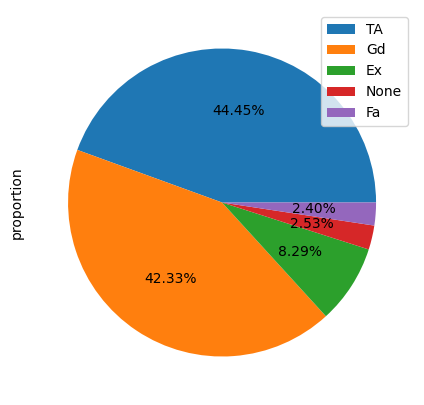

BsmtCond
TA      0.897945
Gd      0.044521
Fa      0.030822
None    0.025342
Po      0.001370
Name: proportion, dtype: float64


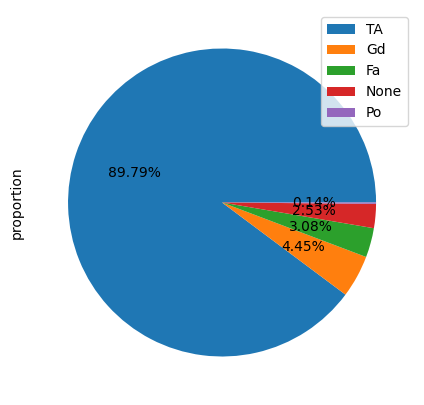

BsmtExposure
No      0.652740
Av      0.151370
Gd      0.091781
Mn      0.078082
None    0.026027
Name: proportion, dtype: float64


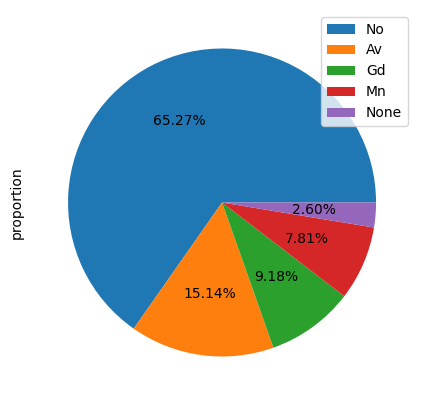

BsmtFinType1
Unf     0.294521
GLQ     0.286301
ALQ     0.150685
BLQ     0.101370
Rec     0.091096
LwQ     0.050685
None    0.025342
Name: proportion, dtype: float64


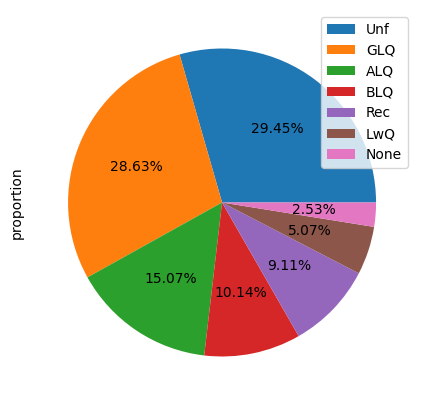

BsmtFinType2
Unf     0.860274
Rec     0.036986
LwQ     0.031507
None    0.026027
BLQ     0.022603
ALQ     0.013014
GLQ     0.009589
Name: proportion, dtype: float64


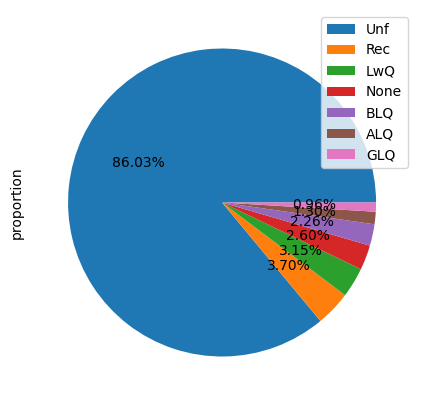

Heating
GasA     0.978082
GasW     0.012329
Grav     0.004795
Wall     0.002740
OthW     0.001370
Floor    0.000685
Name: proportion, dtype: float64


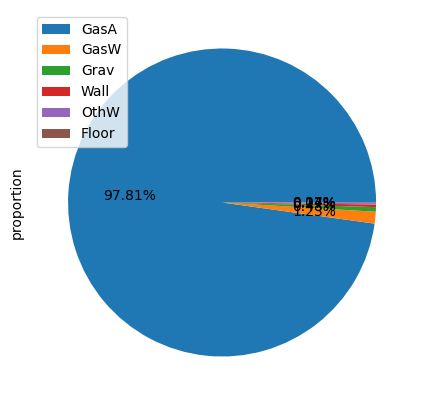

HeatingQC
Ex    0.507534
TA    0.293151
Gd    0.165068
Fa    0.033562
Po    0.000685
Name: proportion, dtype: float64


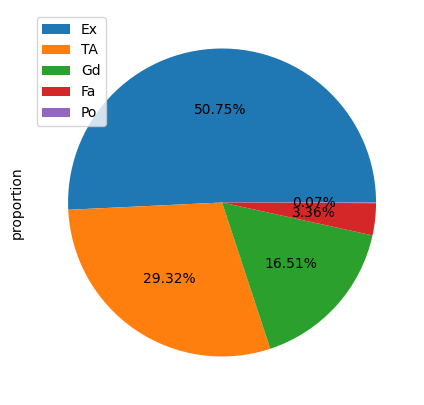

CentralAir
Y    0.934932
N    0.065068
Name: proportion, dtype: float64


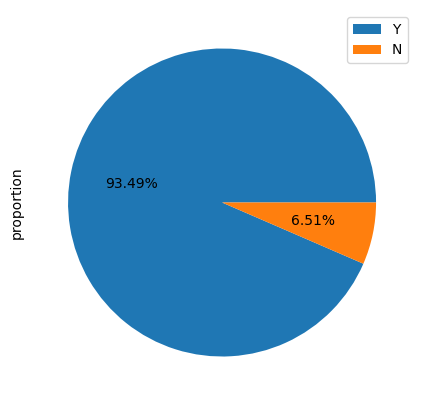

Electrical
SBrkr    0.914384
FuseA    0.064384
FuseF    0.018493
FuseP    0.002055
Mix      0.000685
Name: proportion, dtype: float64


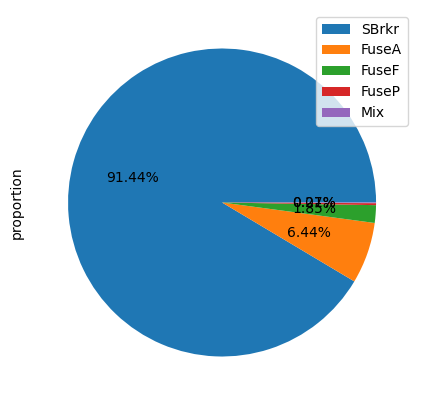

KitchenQual
TA    0.503425
Gd    0.401370
Ex    0.068493
Fa    0.026712
Name: proportion, dtype: float64


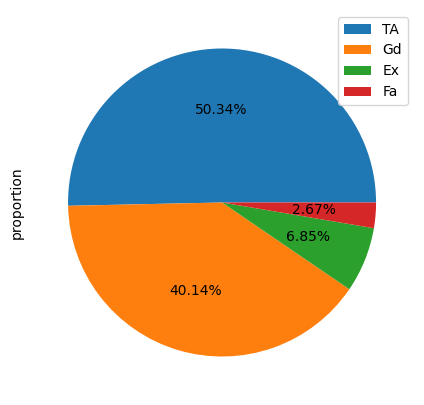

Functional
Typ     0.931507
Min2    0.023288
Min1    0.021233
Mod     0.010274
Maj1    0.009589
Maj2    0.003425
Sev     0.000685
Name: proportion, dtype: float64


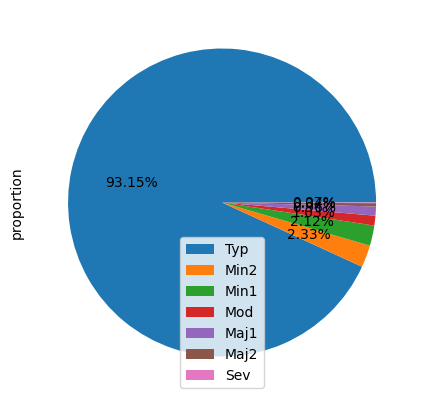

FireplaceQu
None    0.472603
Gd      0.260274
TA      0.214384
Fa      0.022603
Ex      0.016438
Po      0.013699
Name: proportion, dtype: float64


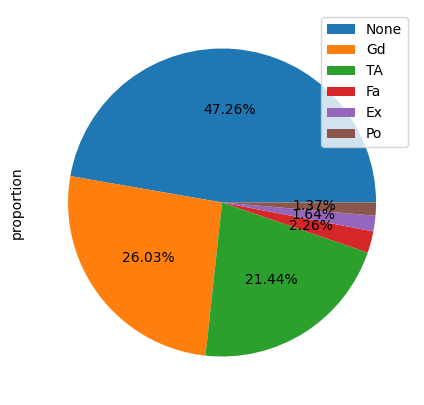

GarageType
Attchd     0.595890
Detchd     0.265068
BuiltIn    0.060274
None       0.055479
Basment    0.013014
CarPort    0.006164
2Types     0.004110
Name: proportion, dtype: float64


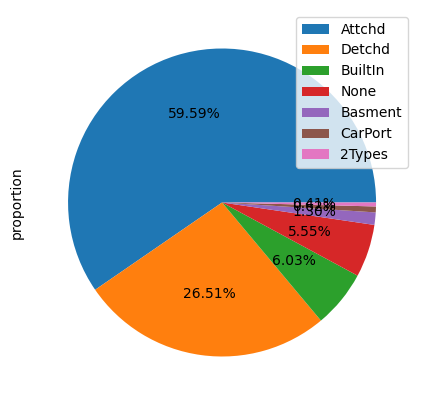

GarageYrBlt
None      0.055479
2005.0    0.044521
2006.0    0.040411
2004.0    0.036301
2003.0    0.034247
            ...   
1900.0    0.000685
1927.0    0.000685
1906.0    0.000685
1908.0    0.000685
1933.0    0.000685
Name: proportion, Length: 98, dtype: float64


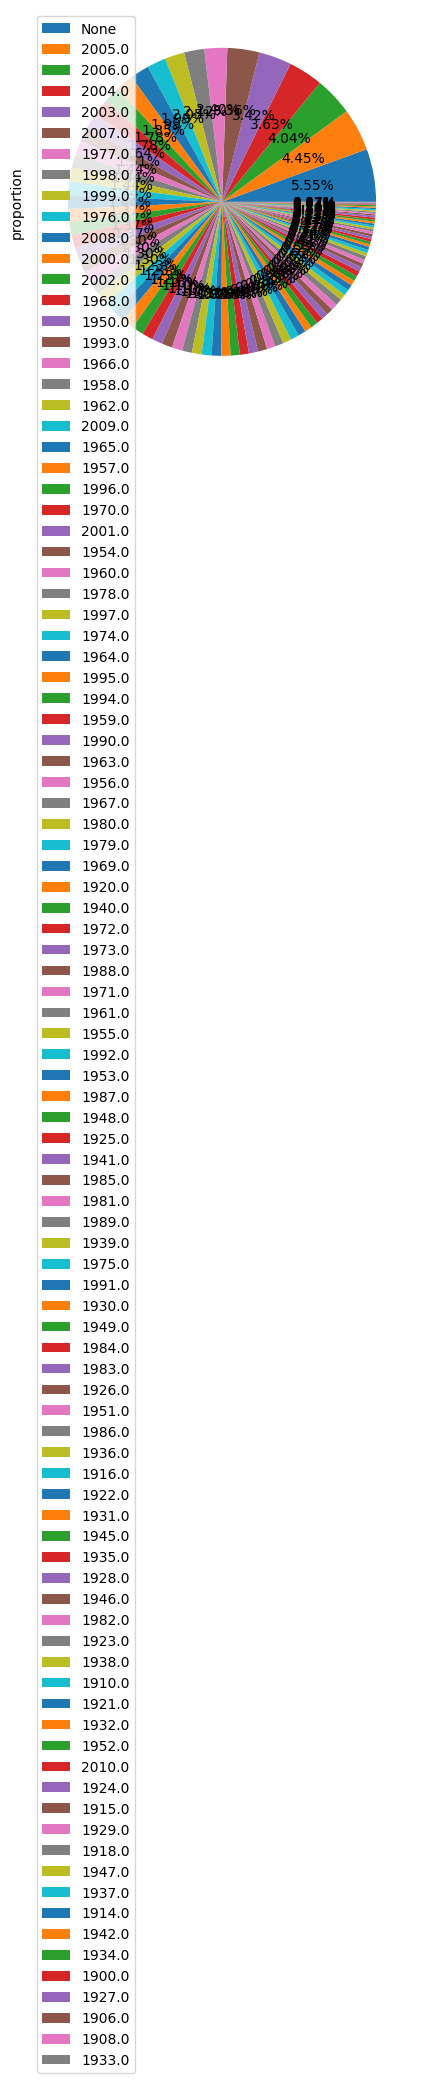

GarageFinish
Unf     0.414384
RFn     0.289041
Fin     0.241096
None    0.055479
Name: proportion, dtype: float64


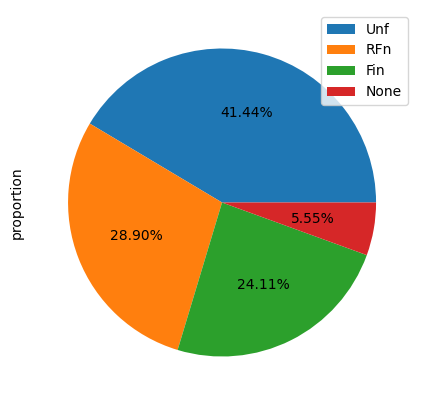

GarageQual
TA      0.897945
None    0.055479
Fa      0.032877
Gd      0.009589
Ex      0.002055
Po      0.002055
Name: proportion, dtype: float64


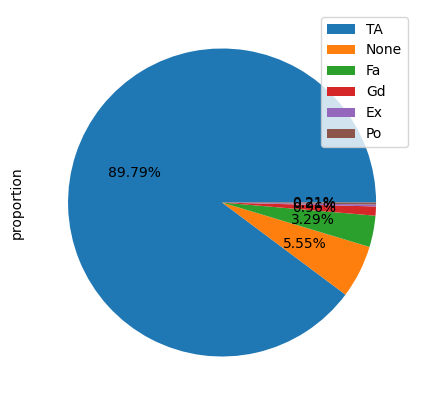

GarageCond
TA      0.908219
None    0.055479
Fa      0.023973
Gd      0.006164
Po      0.004795
Ex      0.001370
Name: proportion, dtype: float64


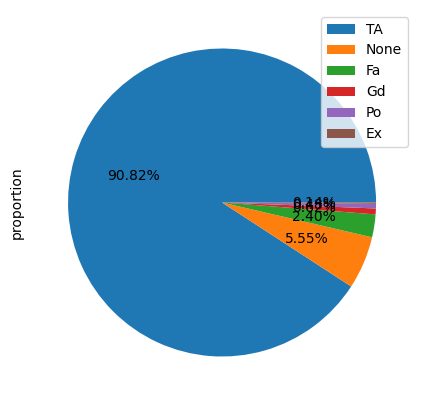

PavedDrive
Y    0.917808
N    0.061644
P    0.020548
Name: proportion, dtype: float64


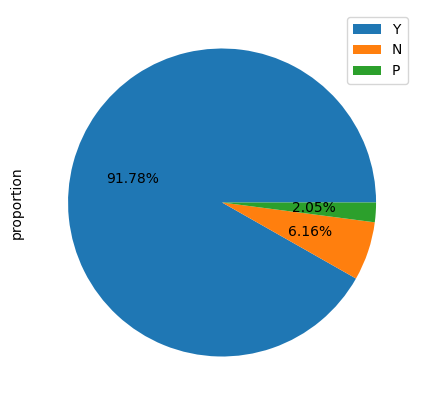

PoolQC
None    0.995205
Gd      0.002055
Ex      0.001370
Fa      0.001370
Name: proportion, dtype: float64


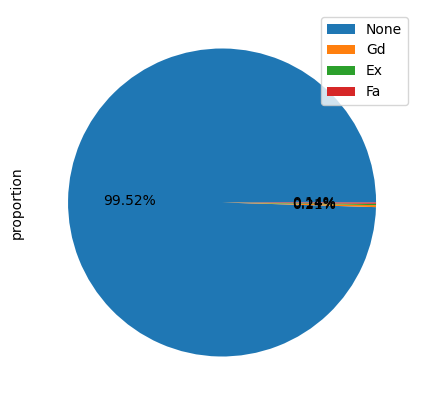

Fence
None     0.807534
MnPrv    0.107534
GdPrv    0.040411
GdWo     0.036986
MnWw     0.007534
Name: proportion, dtype: float64


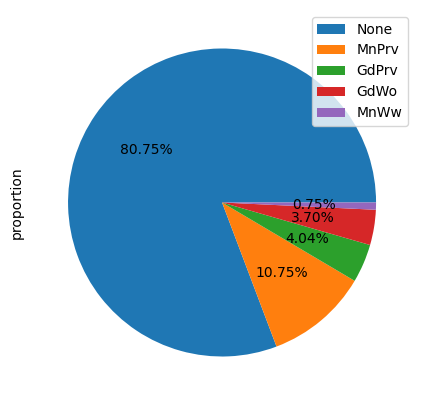

MiscFeature
None    0.963014
Shed    0.033562
Gar2    0.001370
Othr    0.001370
TenC    0.000685
Name: proportion, dtype: float64


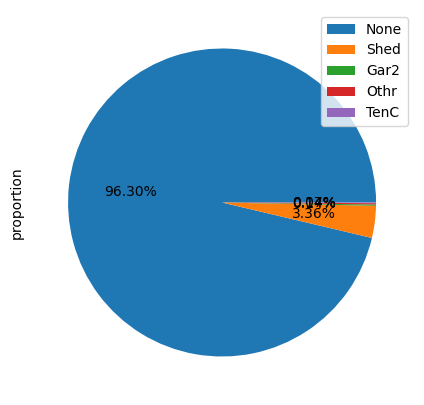

SaleType
WD       0.867808
New      0.083562
COD      0.029452
ConLD    0.006164
ConLI    0.003425
ConLw    0.003425
CWD      0.002740
Oth      0.002055
Con      0.001370
Name: proportion, dtype: float64


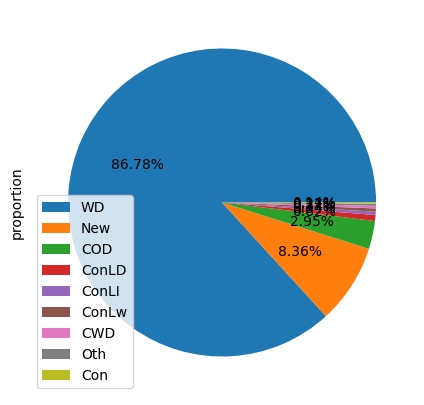

SaleCondition
Normal     0.820548
Partial    0.085616
Abnorml    0.069178
Family     0.013699
Alloca     0.008219
AdjLand    0.002740
Name: proportion, dtype: float64


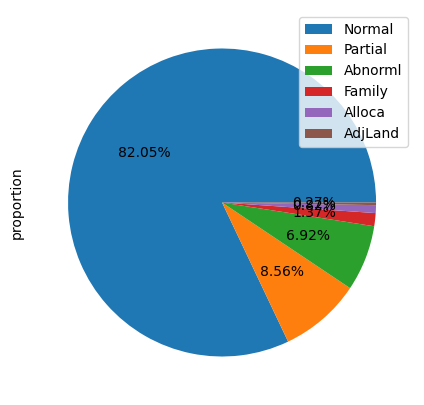

In [23]:
# categorical columns
# plot pie charts to visualize the distribution of each category 

for i in cat_cols:
    print(df[i].value_counts(normalize=True))
    plt.figure(figsize=(5,5))
    df[i].value_counts(normalize=True).plot.pie(labeldistance=None , autopct = '%1.2f%%')
    plt.legend()
    plt.show()
    

### Bivariate/Multivariate Analysis on the dataset

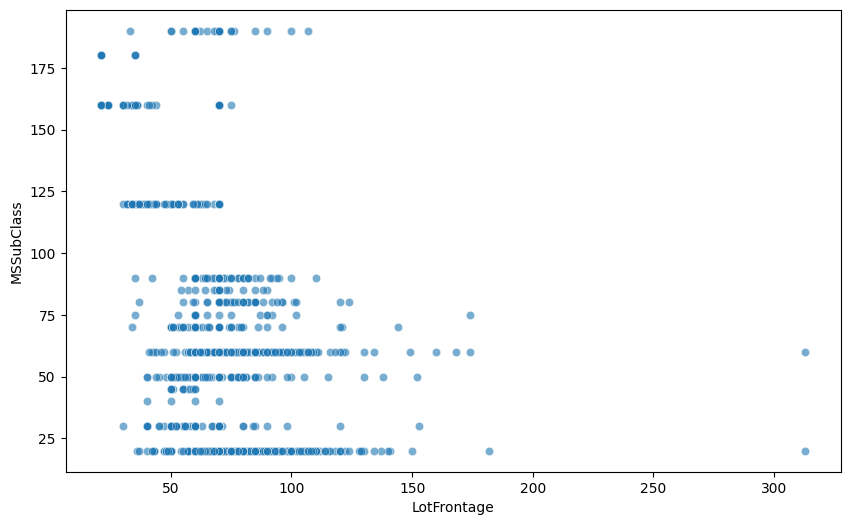

In [24]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='LotFrontage',
    y='MSSubClass',
    data=df,
    alpha=0.6
)

plt.show()

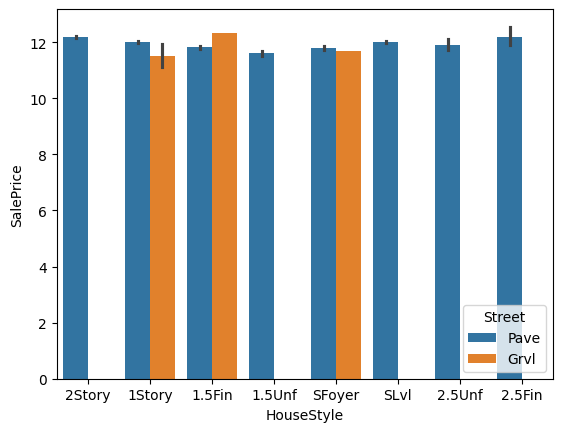

In [25]:
# plot of HouseStyle vs SalePrice based on street
sns.barplot(x='HouseStyle' , y='SalePrice', hue='Street', data=df)
plt.show()

C:\Users\rajve\AppData\Local\Temp\ipykernel_13456\1446703981.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='BldgType', y='SalePrice', data=df,palette='coolwarm')


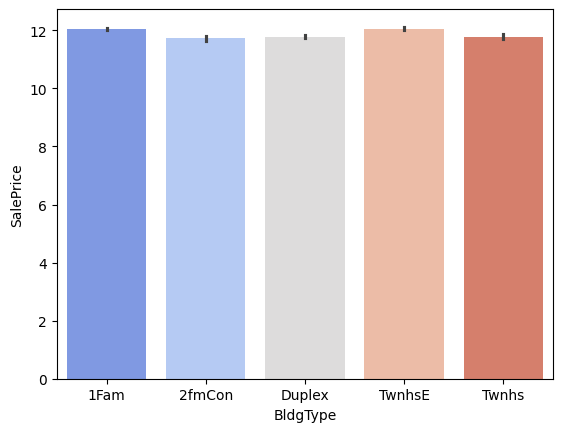

In [26]:
# plot of BldgType vs SalePrice 
sns.barplot(x='BldgType', y='SalePrice', data=df,palette='coolwarm')
plt.show()

C:\Users\rajve\AppData\Local\Temp\ipykernel_13456\2825968155.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='BsmtQual',y='SalePrice', data=df,palette='magma')


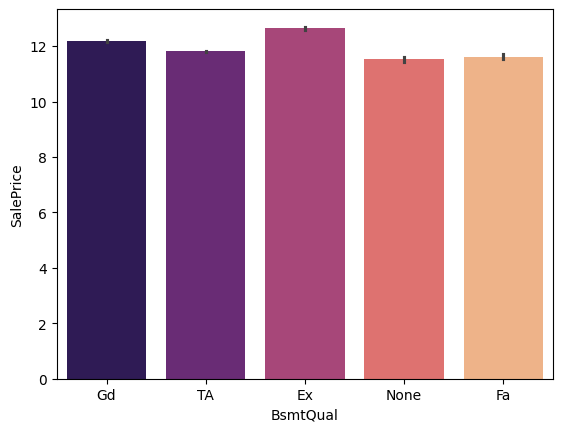

In [27]:
# plot of BsmtQual vs SalePrice
sns.barplot(x='BsmtQual',y='SalePrice', data=df,palette='magma')
plt.show()


##### Conclusion
- we can see that RL h the highest lot frontage and RM  has the least 
- we can see that 2-STORY 1946 & NEWER has the highest lot frontage and PUD- MULTILEVEL-INCL SPLIT LEV/FOYER has the least
- The saleprice is not showing much variance with respect to the style of dwelling(one story/two story)
- The saleprice is almost same for all the building types 

In [29]:
# age of the property
df['Age']= df['YrSold']-df['YearBuilt']
df['Age'].head()

0     5
1    31
2     7
3    91
4     8
Name: Age, dtype: int64

In [30]:
# drop the YrSold and YearBuilt columns
df.drop(columns=['YrSold','YearBuilt'],axis=1,inplace=True)
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,SaleType,SaleCondition,SalePrice,Age
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,None,None,0,2,WD,Normal,12.247694,5
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,0,None,None,None,0,5,WD,Normal,12.109011,31
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,0,None,None,None,0,9,WD,Normal,12.317167,7
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,None,0,2,WD,Abnorml,11.849398,91
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,0,None,None,None,0,12,WD,Normal,12.429216,8


#### Correlation Between Numerical Columns

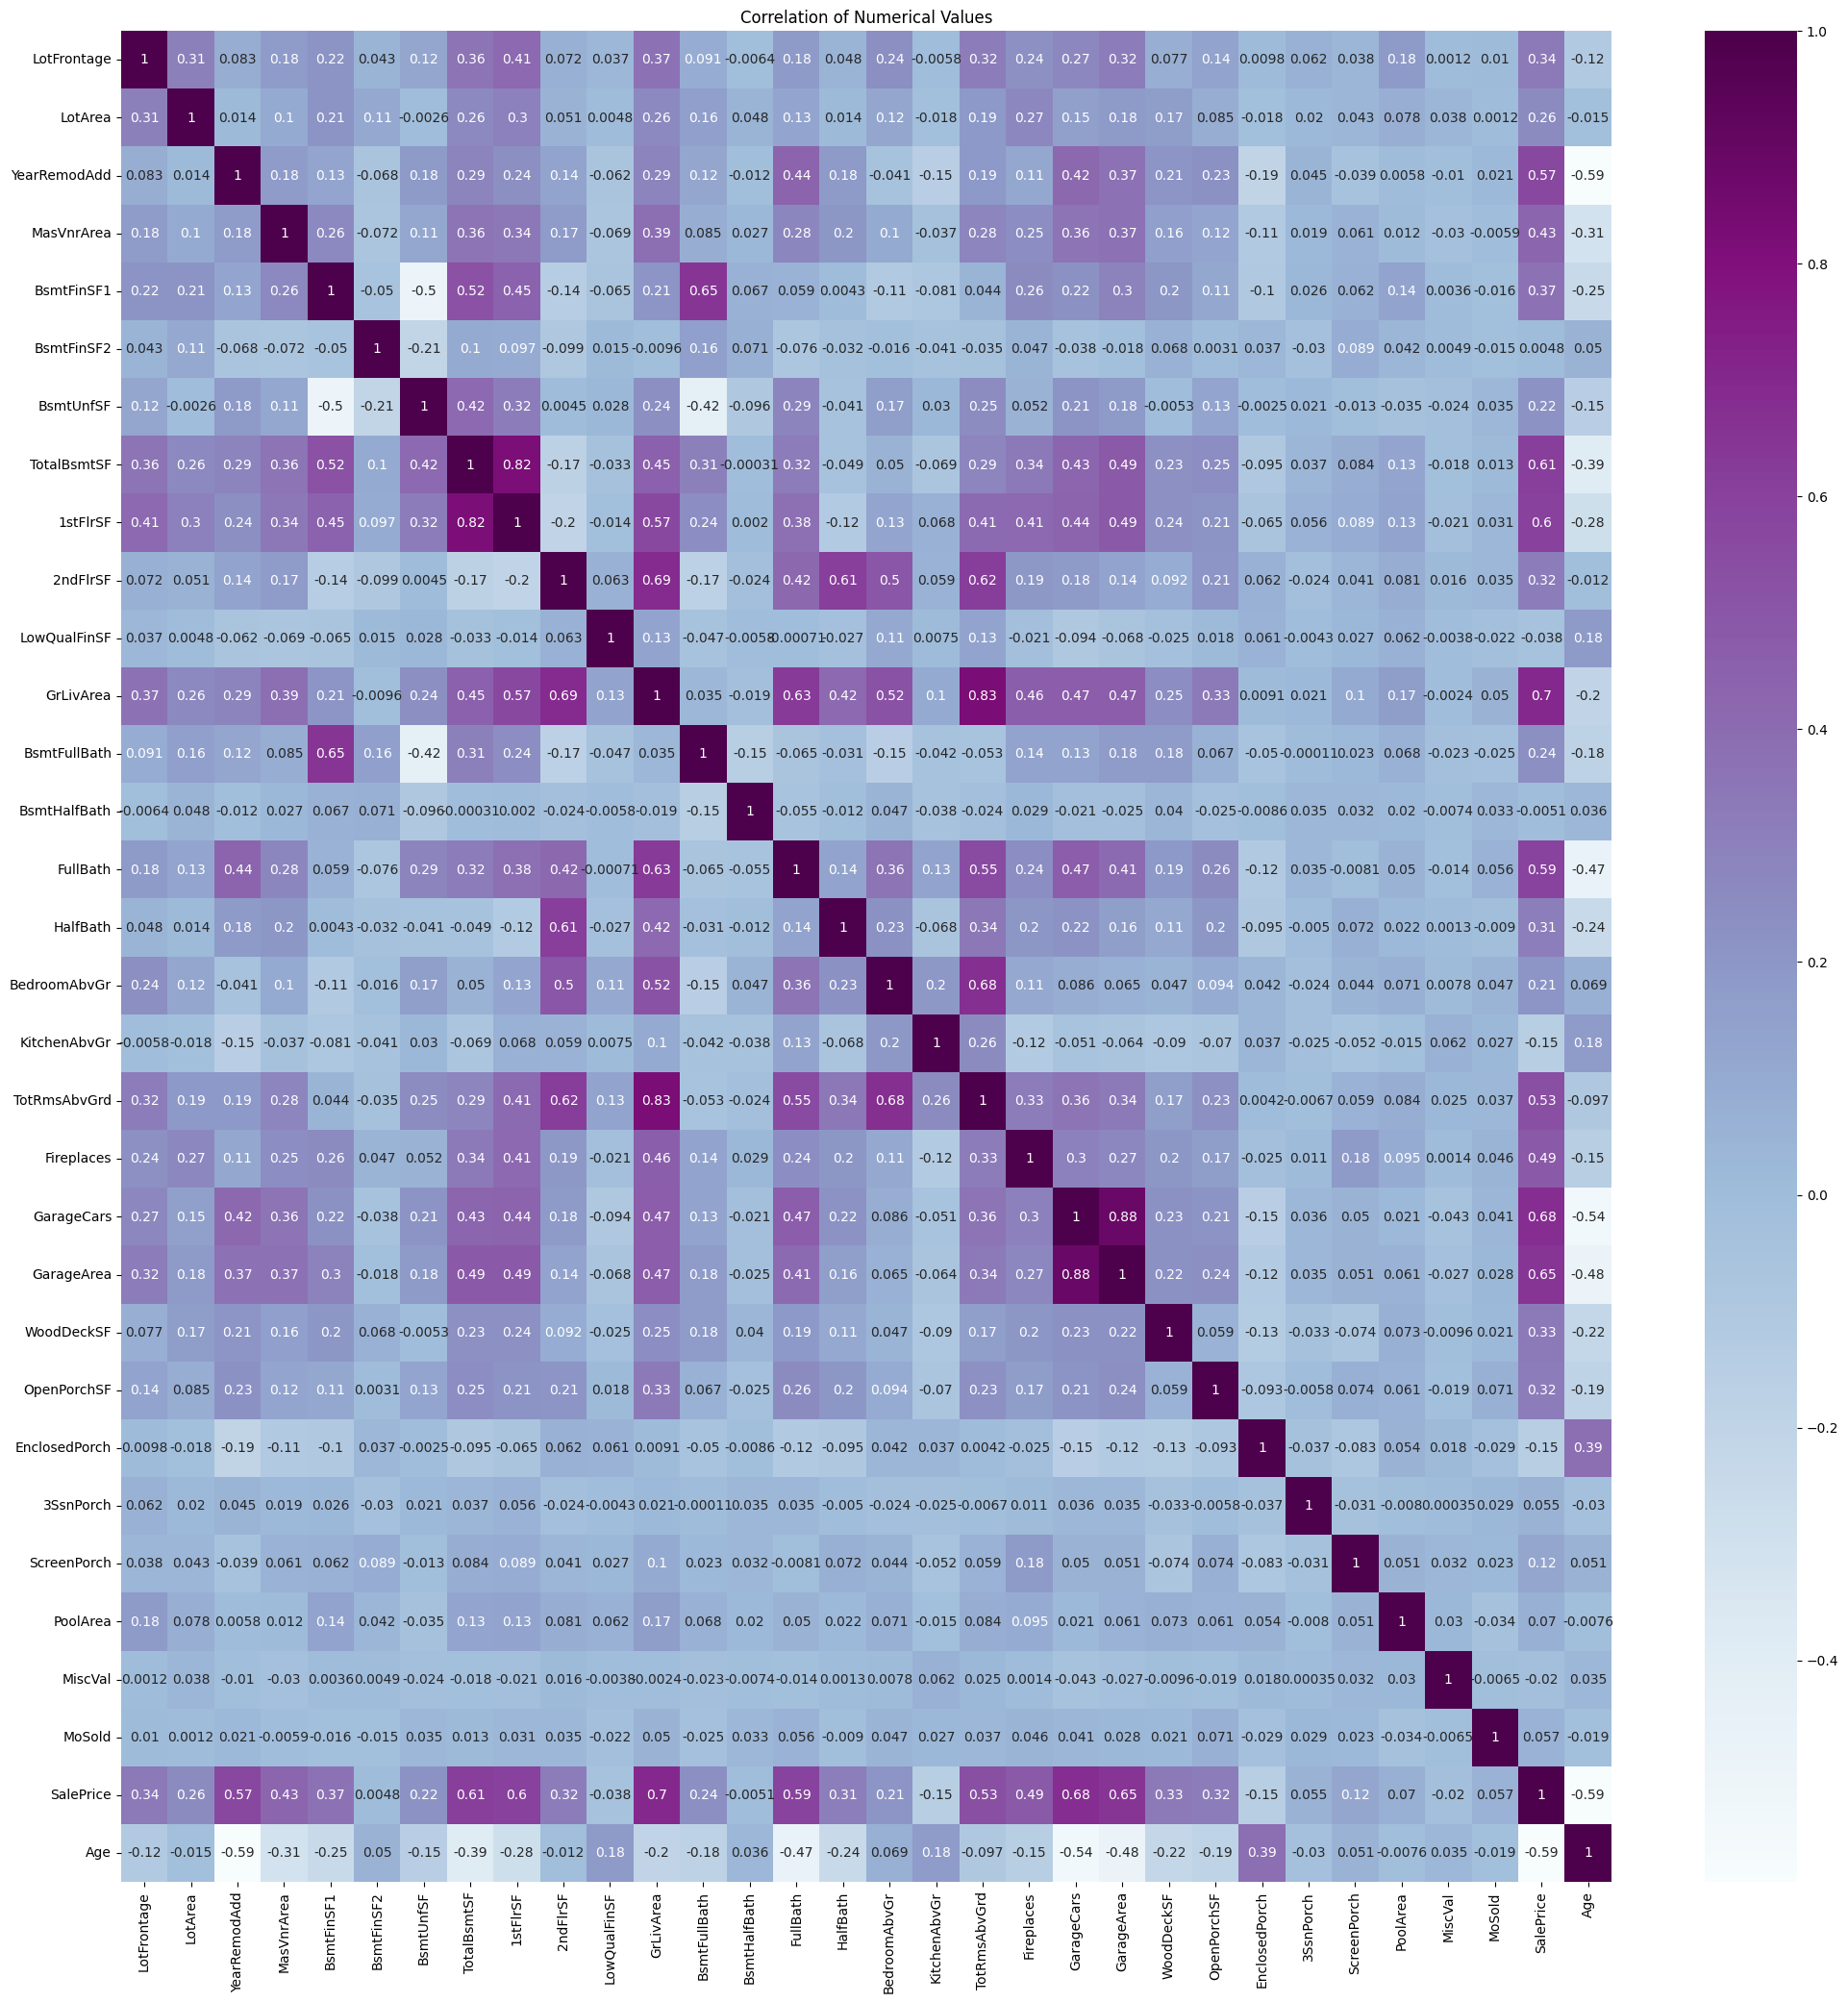

In [33]:
plt.figure(figsize=[25,25])
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='BuPu')
plt.title('Correlation of Numerical Values')
plt.show()

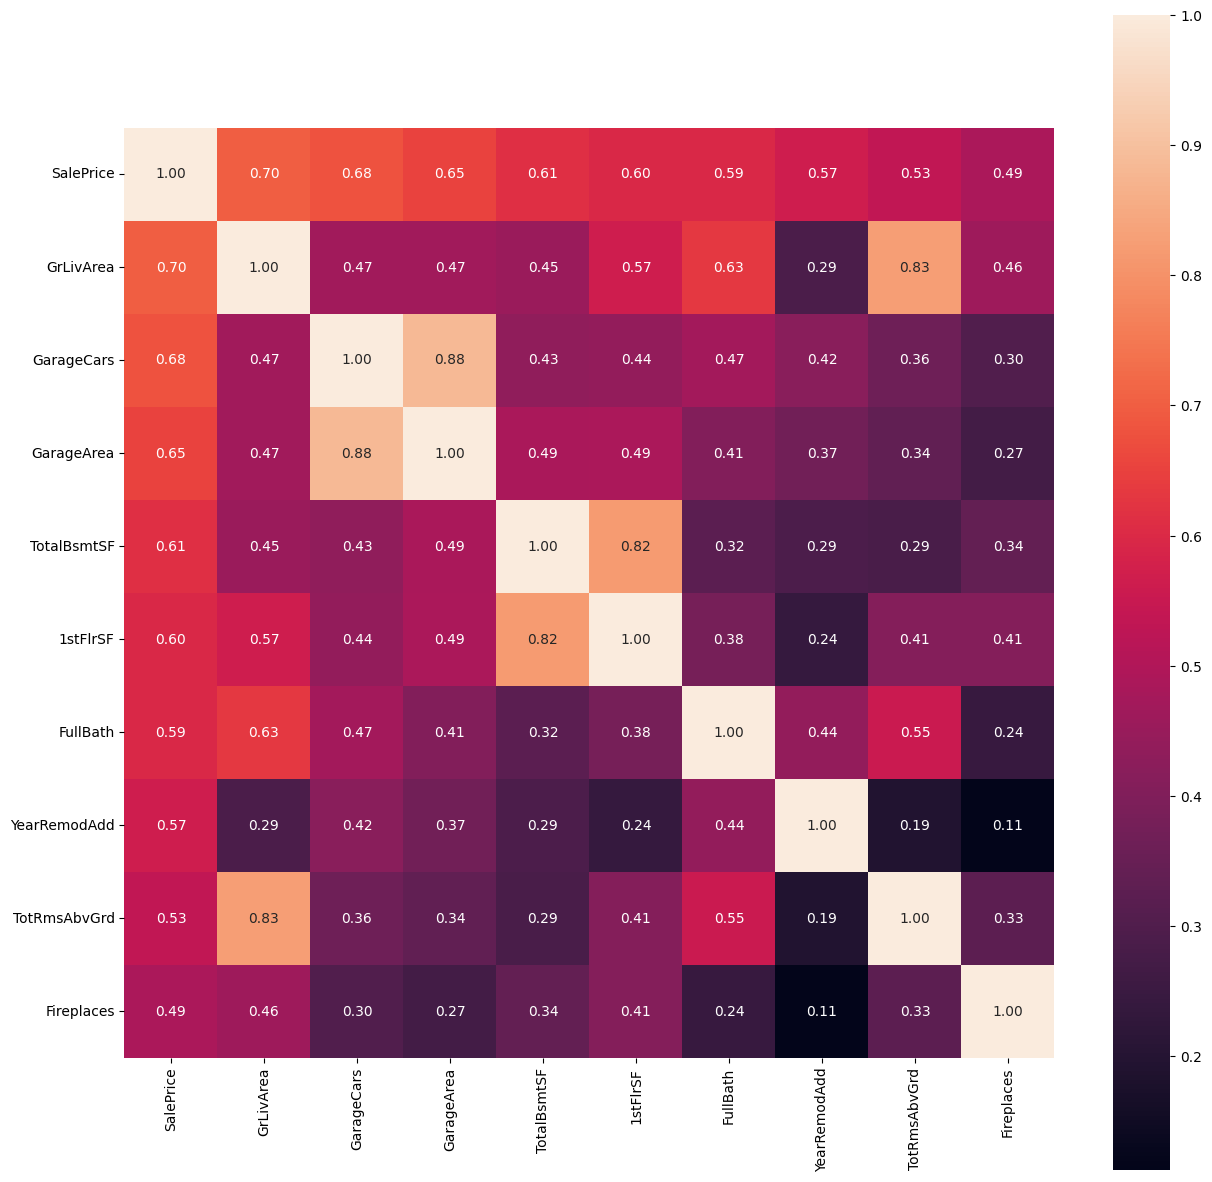

In [35]:
# get top 10 correlated columns
k=10
plt.figure(figsize=[15,15])
cols=df.corr(numeric_only=True).nlargest(k,"SalePrice").index
cm=np.corrcoef(df[cols].values.T)
sns.heatmap(
    cm,
    annot=True,
    square=True,
    fmt='.2f',
    cbar=True,
    annot_kws={'size':10},
    yticklabels=cols.values,
    xticklabels=cols.values
)
plt.show()
            

#### We can see that
- GarageArea and GarageCars are highly correlated with coeff. 0.88
- GrLivArea and TotRmsAbvGrd are highly correlated with coeff of 0.83
- TotalBsmtSF anfd FirstFlrSF   are highly correlated with coeff of 0.82

#### PairPlot for Numerical Columns

<Figure size 2000x2000 with 0 Axes>

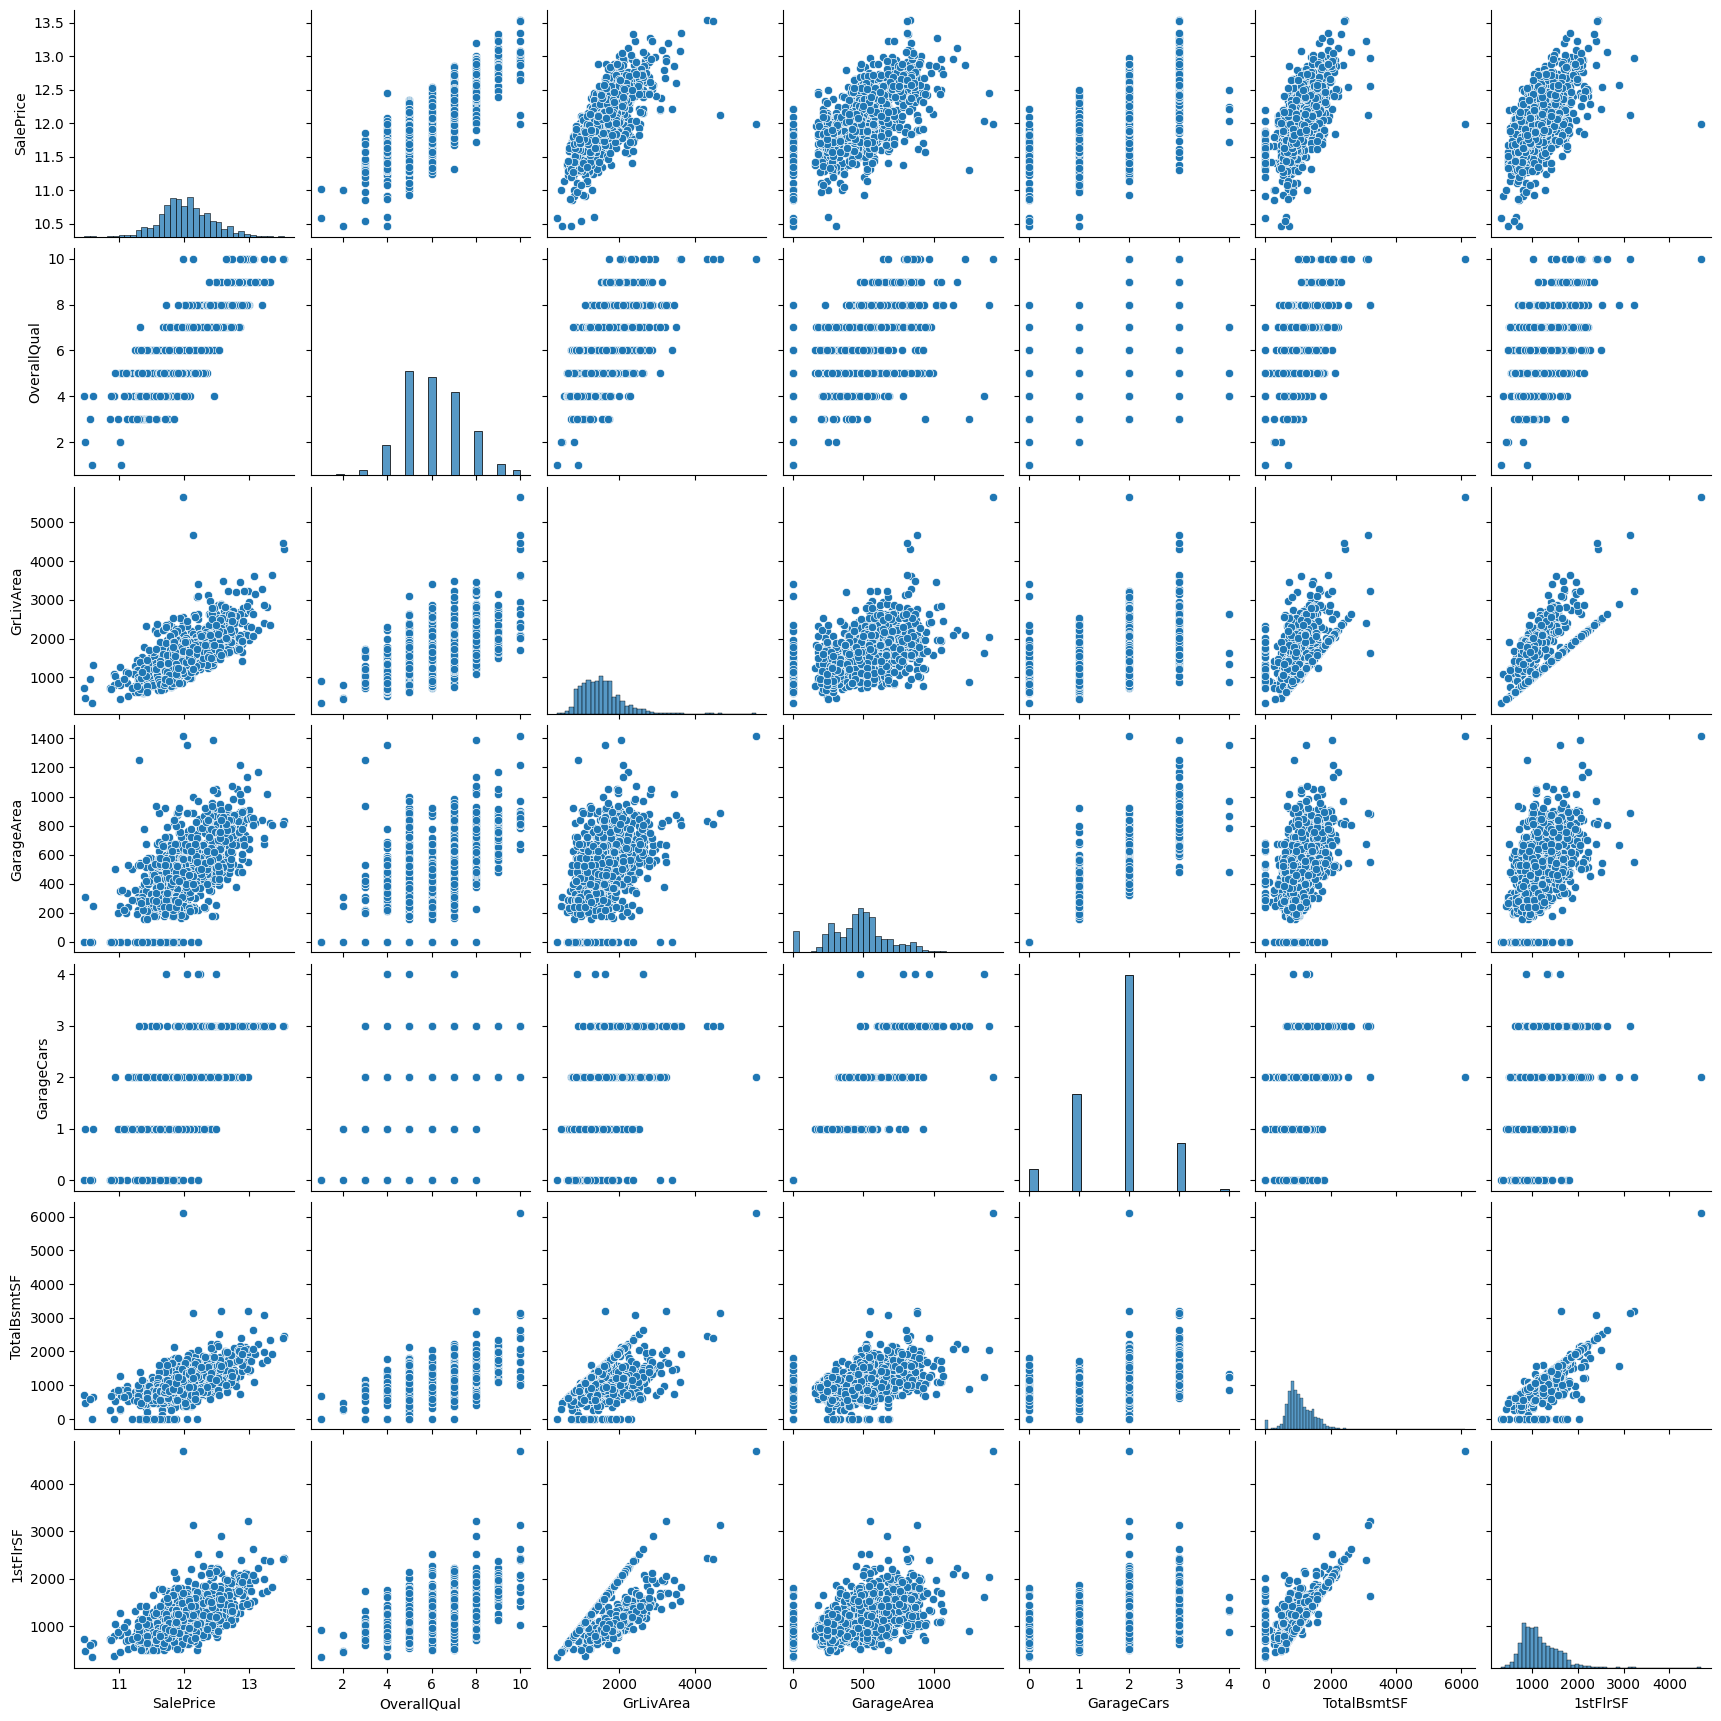

In [37]:
cols= ["SalePrice","OverallQual", "GrLivArea","GarageArea","GarageCars","TotalBsmtSF","1stFlrSF"]
plt.figure(figsize=[20,20])
sns.pairplot(df[cols])
plt.show()

#### Data Preparation

In [40]:
df_num= df.select_dtypes(include=['int64','float64'])
df_cat= df.select_dtypes(include='object')


In [41]:
# dummy values
df_cat_dm= pd.get_dummies(df_cat,drop_first=True,dtype=int)
df_cat_dm

,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1456,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1457,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1458,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0


In [43]:
df1= pd.concat([df_num,df_cat_dm], axis=1)
df1

,LotFrontage,LotArea,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,65.0,8450,2003,196.0,706,0,150,856,856,854,...,0,0,0,0,1,0,0,0,1,0
1,80.0,9600,1976,0.0,978,0,284,1262,1262,0,...,0,0,0,0,1,0,0,0,1,0
2,68.0,11250,2002,162.0,486,0,434,920,920,866,...,0,0,0,0,1,0,0,0,1,0
3,60.0,9550,1970,0.0,216,0,540,756,961,756,...,0,0,0,0,1,0,0,0,0,0
4,84.0,14260,2000,350.0,655,0,490,1145,1145,1053,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,62.0,7917,2000,0.0,0,0,953,953,953,694,...,0,0,0,0,1,0,0,0,1,0
1456,85.0,13175,1988,119.0,790,163,589,1542,2073,0,...,0,0,0,0,1,0,0,0,1,0
1457,66.0,9042,2006,0.0,275,0,877,1152,1188,1152,...,0,0,0,0,1,0,0,0,1,0
1458,68.0,9717,1996,0.0,49,1029,0,1078,1078,0,...,0,0,0,0,1,0,0,0,1,0


In [44]:
# split the dataset into target and feature variables
x= df1.drop(['SalePrice'],axis=1).copy()
y=df1['SalePrice'].copy()

In [45]:
x.head()

,LotFrontage,LotArea,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,65.0,8450,2003,196.0,706,0,150,856,856,854,...,0,0,0,0,1,0,0,0,1,0
1,80.0,9600,1976,0.0,978,0,284,1262,1262,0,...,0,0,0,0,1,0,0,0,1,0
2,68.0,11250,2002,162.0,486,0,434,920,920,866,...,0,0,0,0,1,0,0,0,1,0
3,60.0,9550,1970,0.0,216,0,540,756,961,756,...,0,0,0,0,1,0,0,0,0,0
4,84.0,14260,2000,350.0,655,0,490,1145,1145,1053,...,0,0,0,0,1,0,0,0,1,0


In [46]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.3, random_state=28)
x_train.shape

(1022, 381)

In [48]:
y_test.shape

(438,)

#### Scale the dataset

In [49]:
num_cols= list(x_train.select_dtypes(include=['int64','float64']).columns)

In [52]:
scaler=StandardScaler()
x_train[num_cols]= scaler.fit_transform(x_train[num_cols])
x_test[num_cols]=scaler.fit_transform(x_test[num_cols])


#### Building a Function to calculate evaluation metrices

In [53]:
from sklearn.metrics import mean_squared_error, r2_score

def eval_metrics(y_train,y_train_pred, y_test,y_pred):
    
    # r2 values for train and test data
    print("r2 score (train) - ", '%.2f' % r2_score(y_train,y_train_pred))
    print("r2 score ( test) -", "%.2f" % r2_score(y_test,y_pred))
    
    # RMSE for train and test data
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test= mean_squared_error(y_test,y_pred)
    rmse_train= mse_train ** 0.5
    rmse_test= mse_test ** 0.5
    
    print("RMSE(Train) - ", "%.2f" % rmse_train)
    print("RMSE(Test) -", "%.2F" % rmse_test)
    

#### ML  Model

In [55]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge , Lasso
from sklearn.model_selection import GridSearchCV

In [56]:
# applying ridge regressing with varying the hyperparameter "lambda"

params= {'alpha':
    [0.0001,0.001,0.01,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10,20,50,100,500,1000]}

ridge= Ridge()
ridgeCV = GridSearchCV(estimator=ridge, param_grid=params,scoring='neg_mean_absolute_error',cv=5,return_train_score=True,verbose=1,n_jobs=-1)
ridgeCV.fit(x_train, y_train)


Fitting 5 folds for each of 28 candidates, totalling 140 fits


,estimator,Ridge()
,param_grid,"{'alpha': [0.0001, 0.001, ...]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,alpha,500


In [58]:
ridgeCV.best_params_

{'alpha': 500}

In [59]:
ridgeCV.cv_results_

{'mean_fit_time': array([0.08998618, 0.09335518, 0.08655334, 0.06242738, 0.05382767,
        0.05505762, 0.04516573, 0.05039363, 0.04820771, 0.04152794,
        0.04148607, 0.04560423, 0.04587016, 0.05438533, 0.05195222,
        0.04545827, 0.04094391, 0.0495831 , 0.04846663, 0.04861217,
        0.04025779, 0.03747802, 0.03622065, 0.04122109, 0.03606615,
        0.04377618, 0.0370193 , 0.03301449]),
 'std_fit_time': array([0.00523248, 0.0066085 , 0.00552865, 0.01754412, 0.00485012,
        0.00498788, 0.0098516 , 0.0093517 , 0.00468393, 0.00766205,
        0.00510035, 0.00570777, 0.00934922, 0.00560491, 0.00453237,
        0.00510529, 0.00254247, 0.0071905 , 0.00830126, 0.00723432,
        0.00645392, 0.00318221, 0.00200157, 0.00631227, 0.00322359,
        0.00742683, 0.00362498, 0.0036907 ]),
 'mean_score_time': array([0.02029371, 0.02160182, 0.02257676, 0.01850615, 0.0150876 ,
        0.01518312, 0.01491923, 0.01565595, 0.01412854, 0.01228542,
        0.01300492, 0.01401196, 0.013176

In [60]:
ridge= Ridge(alpha=500)

In [61]:
ridge.fit(x_train,y_train)

,alpha,500
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [62]:
ridge.coef_

array([ 8.65010190e-03,  1.34732655e-02,  1.63791091e-02,  7.75142979e-03,
        2.06847079e-02,  2.77679236e-03,  3.39163871e-03,  2.64521539e-02,
        2.81953119e-02,  1.53740756e-02, -2.14367087e-04,  3.40241190e-02,
        1.11405740e-02, -6.97030671e-05,  1.82600535e-02,  1.15310252e-02,
        3.77249580e-03, -5.25288289e-03,  1.95902612e-02,  1.64120075e-02,
        1.70255099e-02,  1.81486849e-02,  1.18195726e-02,  1.22967236e-02,
       -1.34142399e-03,  2.91658525e-03,  1.15280885e-02,  4.29061210e-03,
        1.36030415e-03,  1.65411951e-04, -1.28918332e-02, -1.60531950e-02,
        1.91126159e-03, -4.84604180e-04,  2.03312158e-03,  4.77327241e-03,
        7.38450676e-03,  8.82401216e-04,  1.06277185e-04, -1.28089384e-03,
       -1.17898910e-03, -3.17261691e-03, -6.47640577e-03, -3.22218779e-03,
       -2.62907186e-03,  6.51530327e-03, -3.30600649e-04,  1.04989873e-02,
       -6.60507884e-03,  5.13313989e-03,  2.70359702e-03,  2.08933062e-04,
        6.15095826e-03,  